# CDS6344 Social Media Computing  
## Assignment Part 3: Project Code Repository  

### Project Title  
**Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning, Transformer Models, and Opinion Spam Detection**

### Group Information  

| Group Number | Student Name | Student ID |
|---|---|---|
| 9 | Venggadanaathan | 1231303562 |
| 9 | Tharraniah Tamilwanan | 1211111799 |

### Notebook 4 Purpose  
This notebook adds an **Opinion Spam Detection** module to the project.

The purpose of this notebook is to identify potentially suspicious or low-quality app reviews using rule-based and similarity-based spam-risk detection methods.

Since the AWARE Social Networking dataset does not provide manually verified spam labels, this notebook does not claim to train a fully supervised spam classifier. Instead, it creates a **spam-risk scoring framework** based on review characteristics.

### Main Tasks in Notebook 4

1. Load the cleaned review-level dataset from Notebook 1  
2. Create review-centric spam-risk features  
3. Detect exact duplicates and near-duplicate reviews  
4. Identify rating-text conflict  
5. Generate spam-risk scores  
6. Categorize reviews into Low, Medium, and High spam-risk groups  
7. Export spam-risk datasets and visualizations  

### Final Output

The final output of this notebook will be:

- `review_level_social_reviews_with_spam_risk.csv`
- `potential_spam_reviews.csv`
- `spam_cleaned_review_level_dataset.csv`
- spam-risk summary tables
- spam-risk visualizations

# 1. Why Opinion Spam Detection Is Added

Opinion spam detection is added because review-based sentiment analysis can be affected by suspicious, duplicate, deceptive, or low-quality reviews.

Lecture 6 explains that opinion/review spam can include:

1. **Untruthful opinions**  
   Reviews that deliberately mislead readers or automated systems.

2. **Reviews on brands only**  
   Reviews that discuss the brand or seller generally instead of the specific product or service.

3. **Non-reviews**  
   Advertisements, irrelevant content, or text without meaningful opinion.

The lecture also highlights duplicate and near-duplicate reviews as important indicators of possible opinion spam.

Because this dataset does not contain official spam labels, this notebook uses a **spam-risk detection framework** instead of a supervised spam classifier.

The spam-risk score is based on:

| Spam Signal | Reason |
|---|---|
| Exact duplicate review text | Duplicate reviews may indicate repeated or copied content |
| Near-duplicate review text | Similar reviews may indicate template-like or repeated review patterns |
| Very short review | Short generic reviews may provide limited useful opinion |
| Excessive capitalization | May indicate promotional or low-quality content |
| Repeated punctuation | May indicate exaggeration or spam-like expression |
| URL or promotional terms | May indicate advertisement or irrelevant content |
| Rating-text conflict | High rating with negative text or low rating with positive text may be suspicious |
| Rating deviation by app | Extreme rating differences from app average may indicate outlier behaviour |

The goal is not to remove reviews automatically, but to support data reliability analysis and provide an additional project component.

# 2. Notebook 4 Phase Plan

Notebook 4 is divided into six phases:

| Phase | Name | Purpose |
|---:|---|---|
| 1 | Setup and Load Dataset | Load cleaned review-level dataset from Notebook 1 |
| 2 | Spam-Risk Feature Engineering | Create review-centric spam indicators |
| 3 | Duplicate and Near-Duplicate Detection | Identify exact and highly similar reviews |
| 4 | Spam-Risk Scoring | Combine indicators into Low, Medium, and High risk |
| 5 | Spam-Risk Visualization and Analysis | Create tables and charts for report |
| 6 | Final Export | Export spam-risk datasets and ZIP output |

This notebook supports the report section on data reliability and opinion spam detection.

In [1]:
# ============================================================
# NOTEBOOK 4 - INSTALL REQUIRED LIBRARIES
# ============================================================
# This notebook uses common Python libraries for:
# - data handling
# - text processing
# - similarity detection
# - visualization
#
# scikit-learn is used for TF-IDF and cosine similarity.
# ============================================================

!pip install -q scikit-learn nltk

print("Required libraries installed successfully.")

Required libraries installed successfully.


In [2]:
# ============================================================
# NOTEBOOK 4 - IMPORT LIBRARIES
# ============================================================
# This cell imports all libraries needed for opinion spam-risk
# detection and visualization.
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import zipfile
import shutil
import warnings
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# SET RANDOM SEED AND CHART STYLE
# ============================================================
# This improves reproducibility and keeps visuals consistent
# with previous notebooks.
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

MAIN_BLUE = "#2563EB"
MAIN_PURPLE = "#7C3AED"
MAIN_ORANGE = "#F97316"
MAIN_TEAL = "#0D9488"
MAIN_RED = "#DC2626"
MAIN_GREEN = "#16A34A"
MAIN_YELLOW = "#F59E0B"

SPAM_RISK_COLORS = {
    "Low Risk": MAIN_GREEN,
    "Medium Risk": MAIN_YELLOW,
    "High Risk": MAIN_RED
}

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

print("Random seed and chart style configured.")

Random seed and chart style configured.


In [4]:
# ============================================================
# CREATE NOTEBOOK 4 OUTPUT FOLDERS
# ============================================================
# Existing folders are cleared first to avoid mixing older
# outputs with final outputs.
# ============================================================

output_folders = [
    "results_notebook4",
    "visualizations_notebook4",
    "exports_notebook4"
]

for folder in output_folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print("Clean Notebook 4 folders created:")
print("- results_notebook4/")
print("- visualizations_notebook4/")
print("- exports_notebook4/")

Clean Notebook 4 folders created:
- results_notebook4/
- visualizations_notebook4/
- exports_notebook4/


In [5]:
# ============================================================
# BAR LABEL HELPER FUNCTION
# ============================================================
# Adds labels on top of bars for clearer report visuals.
# ============================================================

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=9)

print("Helper function created.")

Helper function created.


In [6]:
# ============================================================
# UPLOAD CLEANED REVIEW-LEVEL DATASET
# ============================================================
# Upload:
# review_level_social_reviews.csv
#
# This file was created in Notebook 1 and contains one row per
# unique review.
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving review_level_social_reviews.csv to review_level_social_reviews (1).csv


In [7]:
# ============================================================
# LOAD REVIEW-LEVEL DATASET
# ============================================================
# This dataset is used for opinion spam-risk detection because
# spam is usually assessed at the full review level.
# ============================================================

review_file = "review_level_social_reviews.csv"

review_df = pd.read_csv(review_file)

print("Review-level dataset loaded successfully.")
print("Shape:", review_df.shape)

display(review_df.head())

Review-level dataset loaded successfully.
Shape: (1615, 10)


,domain,app,review_id,title,review,rating,rating_sentiment,basic_clean_review,ml_clean_review,review_word_count
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,4,Positive,i like whatsapp to talk to friends that are no...,like whatsapp talk friend not america recently...,96
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,Sharing Screens,"As a mobile user, it is unfortunate that we ca...",4,Positive,as a mobile user it is unfortunate that we can...,mobile user unfortunate cannot share screen mo...,170
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,Great!!,Does everything the desktop app does! Slight b...,5,Positive,does everything the desktop app does slight bu...,everything desktop app slight bug switching wi...,49
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,1,Negative,i logged in today and my credits and history w...,logged today credit history gone number change...,197
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,Wow!,"I’ve been using Skype for years as a gamer, an...",5,Positive,i ve been using skype for years as a gamer and...,using skype year gamer liked mobile recent upd...,136


In [8]:
# ============================================================
# VALIDATE REQUIRED COLUMNS
# ============================================================
# This cell checks that all columns needed for spam-risk detection
# are available.
# ============================================================

required_columns = [
    "domain",
    "app",
    "review_id",
    "title",
    "review",
    "rating",
    "rating_sentiment",
    "basic_clean_review",
    "ml_clean_review"
]

missing_columns = [
    col for col in required_columns
    if col not in review_df.columns
]

if len(missing_columns) == 0:
    print("All required columns are available.")
else:
    print("Missing required columns:")
    print(missing_columns)

All required columns are available.


In [9]:
# ============================================================
# DATASET INFORMATION
# ============================================================
# Shows data types and non-null counts.
# ============================================================

print("Review-level dataset info:")
review_df.info()

Review-level dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   domain              1615 non-null   object
 1   app                 1615 non-null   object
 2   review_id           1615 non-null   object
 3   title               1615 non-null   object
 4   review              1615 non-null   object
 5   rating              1615 non-null   int64 
 6   rating_sentiment    1615 non-null   object
 7   basic_clean_review  1615 non-null   object
 8   ml_clean_review     1615 non-null   object
 9   review_word_count   1615 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 126.3+ KB


In [10]:
# ============================================================
# MISSING VALUES CHECK
# ============================================================
# Missing values are checked before spam-risk feature engineering.
# ============================================================

missing_values = review_df.isnull().sum().sort_values(ascending=False)

missing_values.to_csv(
    "results_notebook4/notebook4_missing_values.csv"
)

print("Missing values:")
print(missing_values)

Missing values:
domain                0
app                   0
review_id             0
title                 0
review                0
rating                0
rating_sentiment      0
basic_clean_review    0
ml_clean_review       0
review_word_count     0
dtype: int64


In [11]:
# ============================================================
# BASIC DATASET SUMMARY
# ============================================================
# This gives a quick overview of the review-level dataset.
# ============================================================

basic_dataset_summary = pd.DataFrame([
    {
        "Metric": "Total Reviews",
        "Value": len(review_df)
    },
    {
        "Metric": "Unique Apps",
        "Value": review_df["app"].nunique()
    },
    {
        "Metric": "Unique Review IDs",
        "Value": review_df["review_id"].nunique()
    },
    {
        "Metric": "Minimum Rating",
        "Value": review_df["rating"].min()
    },
    {
        "Metric": "Maximum Rating",
        "Value": review_df["rating"].max()
    },
    {
        "Metric": "Average Rating",
        "Value": round(review_df["rating"].mean(), 2)
    }
])

basic_dataset_summary.to_csv(
    "results_notebook4/basic_dataset_summary.csv",
    index=False
)

basic_dataset_summary

,Metric,Value
0,Total Reviews,1615.00
1,Unique Apps,6.00
2,Unique Review IDs,1615.00
3,Minimum Rating,1.00
4,Maximum Rating,5.00
5,Average Rating,3.22


In [12]:
# ============================================================
# REVIEW DISTRIBUTION BY APP
# ============================================================
# This checks how many reviews each app contributes.
# Useful later for app-wise spam-risk analysis.
# ============================================================

review_distribution_by_app = (
    review_df["app"]
    .value_counts()
    .reset_index()
)

review_distribution_by_app.columns = ["App", "Review Count"]

review_distribution_by_app["Percentage"] = (
    review_distribution_by_app["Review Count"] /
    review_distribution_by_app["Review Count"].sum() * 100
).round(2)

review_distribution_by_app.to_csv(
    "results_notebook4/review_distribution_by_app.csv",
    index=False
)

review_distribution_by_app

,App,Review Count,Percentage
0,free-tone-calling-texting,471,29.16
1,whatsapp-messenger,273,16.90
2,discord,272,16.84
3,facebook,271,16.78
4,teamspeak-3,234,14.49
5,threema-the-secure-messenger,94,5.82


In [13]:
# ============================================================
# RATING AND SENTIMENT DISTRIBUTION
# ============================================================
# This checks rating distribution and rating-based sentiment
# distribution before spam-risk detection.
# ============================================================

rating_distribution = (
    review_df["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["Rating", "Count"]

rating_distribution["Percentage"] = (
    rating_distribution["Count"] /
    rating_distribution["Count"].sum() * 100
).round(2)

rating_sentiment_distribution = (
    review_df["rating_sentiment"]
    .value_counts()
    .reset_index()
)

rating_sentiment_distribution.columns = ["Rating Sentiment", "Count"]

rating_sentiment_distribution["Percentage"] = (
    rating_sentiment_distribution["Count"] /
    rating_sentiment_distribution["Count"].sum() * 100
).round(2)

rating_distribution.to_csv(
    "results_notebook4/rating_distribution_before_spam_detection.csv",
    index=False
)

rating_sentiment_distribution.to_csv(
    "results_notebook4/rating_sentiment_distribution_before_spam_detection.csv",
    index=False
)

print("Rating distribution:")
display(rating_distribution)

print("\nRating sentiment distribution:")
display(rating_sentiment_distribution)

Rating distribution:


,Rating,Count,Percentage
0,1,396,24.52
1,2,155,9.60
2,3,260,16.10
3,4,313,19.38
4,5,491,30.40



Rating sentiment distribution:


,Rating Sentiment,Count,Percentage
0,Positive,804,49.78
1,Negative,551,34.12
2,Neutral,260,16.10


# 3. Phase 2: Spam-Risk Feature Engineering

This phase creates review-level spam-risk features.

Since the dataset does not contain official spam labels, this project uses a rule-based spam-risk framework. The goal is to identify suspicious reviews that may require manual checking.

The features are inspired by opinion spam concepts discussed in Lecture 6, including review-centric indicators, duplicate/near-duplicate content, abnormal text patterns, and rating deviation.

## Features Created

| Feature | Description |
|---|---|
| Review length | Number of words and characters in the review |
| Very short review flag | Reviews with too few words may be generic or low-information |
| Uppercase ratio | High capitalization may suggest promotional or exaggerated writing |
| Repeated punctuation | Repeated `!!!` or `???` may indicate spam-like exaggeration |
| URL flag | Reviews containing links may be promotional or irrelevant |
| Contact/promotion flag | Reviews containing words like `free`, `download`, `visit`, `http`, or `email` may be suspicious |
| Rating deviation by app | Reviews far from the app's average rating may be rating outliers |
| Rating-text conflict | Rating sentiment disagrees with lexicon-style text sentiment |

These features will later be combined into a spam-risk score.

In [14]:
# ============================================================
# CREATE WORKING COPY FOR SPAM-RISK FEATURES
# ============================================================
# This cell creates a copy of the review-level dataset so the
# original loaded dataframe remains unchanged.
# ============================================================

spam_df = review_df.copy()

# Ensure text columns are strings
spam_df["review"] = spam_df["review"].astype(str)
spam_df["basic_clean_review"] = spam_df["basic_clean_review"].astype(str)
spam_df["ml_clean_review"] = spam_df["ml_clean_review"].astype(str)

print("Working dataframe created.")
print("Shape:", spam_df.shape)

spam_df.head()

Working dataframe created.
Shape: (1615, 10)


,domain,app,review_id,title,review,rating,rating_sentiment,basic_clean_review,ml_clean_review,review_word_count
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,4,Positive,i like whatsapp to talk to friends that are no...,like whatsapp talk friend not america recently...,96
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,Sharing Screens,"As a mobile user, it is unfortunate that we ca...",4,Positive,as a mobile user it is unfortunate that we can...,mobile user unfortunate cannot share screen mo...,170
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,Great!!,Does everything the desktop app does! Slight b...,5,Positive,does everything the desktop app does slight bu...,everything desktop app slight bug switching wi...,49
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,1,Negative,i logged in today and my credits and history w...,logged today credit history gone number change...,197
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,Wow!,"I’ve been using Skype for years as a gamer, an...",5,Positive,i ve been using skype for years as a gamer and...,using skype year gamer liked mobile recent upd...,136


In [15]:
# ============================================================
# REVIEW LENGTH FEATURES
# ============================================================
# Spam-like or low-quality reviews may be extremely short,
# overly repetitive, or unusually long.
#
# Features:
# - character count
# - word count
# - very short review flag
# - very long review flag
# ============================================================

spam_df["review_char_count"] = spam_df["review"].str.len()

spam_df["review_word_count_spam"] = (
    spam_df["review"]
    .str.split()
    .apply(len)
)

# Very short reviews can be low-information or generic.
spam_df["very_short_review_flag"] = (
    spam_df["review_word_count_spam"] <= 5
).astype(int)

# Very long reviews are not always spam, but can be unusual.
# Use the 95th percentile as a data-driven threshold.
long_review_threshold = spam_df["review_word_count_spam"].quantile(0.95)

spam_df["very_long_review_flag"] = (
    spam_df["review_word_count_spam"] >= long_review_threshold
).astype(int)

print("Review length features created.")
print("Long review threshold:", long_review_threshold)

spam_df[
    [
        "review",
        "review_word_count_spam",
        "review_char_count",
        "very_short_review_flag",
        "very_long_review_flag"
    ]
].head()

Review length features created.
Long review threshold: 214.29999999999995


,review,review_word_count_spam,review_char_count,very_short_review_flag,very_long_review_flag
0,I like WhatsApp to talk to friends that aren’t...,94,524,0,0
1,"As a mobile user, it is unfortunate that we ca...",167,927,0,0
2,Does everything the desktop app does! Slight b...,48,262,0,0
3,I logged in today and my credits and history w...,194,959,0,0
4,"I’ve been using Skype for years as a gamer, an...",135,708,0,0


In [16]:
# ============================================================
# UPPERCASE AND PUNCTUATION FEATURES
# ============================================================
# Excessive uppercase letters and repeated punctuation may indicate
# exaggerated, promotional, or low-quality review behaviour.
#
# Features:
# - uppercase ratio
# - high uppercase flag
# - repeated exclamation flag
# - repeated question mark flag
# - repeated punctuation flag
# ============================================================

def calculate_uppercase_ratio(text):
    letters = [char for char in text if char.isalpha()]
    if len(letters) == 0:
        return 0
    uppercase_letters = [char for char in letters if char.isupper()]
    return len(uppercase_letters) / len(letters)


spam_df["uppercase_ratio"] = spam_df["review"].apply(calculate_uppercase_ratio)

# More than 30% uppercase letters is considered high for review text.
spam_df["high_uppercase_flag"] = (
    spam_df["uppercase_ratio"] >= 0.30
).astype(int)

spam_df["repeated_exclamation_flag"] = (
    spam_df["review"].str.contains(r"!{2,}", regex=True)
).astype(int)

spam_df["repeated_question_flag"] = (
    spam_df["review"].str.contains(r"\?{2,}", regex=True)
).astype(int)

spam_df["repeated_punctuation_flag"] = (
    (spam_df["repeated_exclamation_flag"] == 1) |
    (spam_df["repeated_question_flag"] == 1)
).astype(int)

print("Uppercase and punctuation features created.")

spam_df[
    [
        "review",
        "uppercase_ratio",
        "high_uppercase_flag",
        "repeated_exclamation_flag",
        "repeated_question_flag",
        "repeated_punctuation_flag"
    ]
].head()

Uppercase and punctuation features created.


,review,uppercase_ratio,high_uppercase_flag,repeated_exclamation_flag,repeated_question_flag,repeated_punctuation_flag
0,I like WhatsApp to talk to friends that aren’t...,0.033493,0,0,0,0
1,"As a mobile user, it is unfortunate that we ca...",0.029932,0,0,0,0
2,Does everything the desktop app does! Slight b...,0.034146,0,0,0,0
3,I logged in today and my credits and history w...,0.037037,0,0,0,0
4,"I’ve been using Skype for years as a gamer, an...",0.045372,0,0,0,0


In [17]:
# ============================================================
# URL, EMAIL, AND REFINED PROMOTIONAL PATTERN FEATURES
# ============================================================
# Spam or non-review content may contain:
# - URLs
# - email addresses
# - strong external promotional terms
# - suspicious external-action phrases
#
# Important refinement:
# Common app-review words such as "free", "download", "offer",
# and "contact" can naturally appear in app reviews.
#
# Example:
# - "ad-free version"
# - "download problem"
# - "contact support"
#
# Therefore, weak commercial terms are tracked separately but
# are NOT used as strong spam-risk evidence by themselves.
# This reduces false positives.
# ============================================================

url_pattern = r"(http|https|www\.|\.com|\.net|\.org)"
email_pattern = r"\b[\w\.-]+@[\w\.-]+\.\w+\b"

# Strong promotional / external-action terms.
# These are more suspicious than normal app-review words.
strict_promotional_terms = [
    "visit",
    "website",
    "click",
    "subscribe",
    "email",
    "link",
    "deal",
    "win",
    "prize",
    "promo",
    "promotion",
    "discount",
    "limited offer",
    "claim now",
    "sign up"
]

strict_promotion_pattern = (
    r"\b(" + "|".join(strict_promotional_terms) + r")\b"
)

# Weak commercial words are common in app reviews.
# They are tracked for analysis but not used directly as a strong spam score.
weak_commercial_terms = [
    "free",
    "download",
    "offer",
    "contact"
]

weak_commercial_pattern = (
    r"\b(" + "|".join(weak_commercial_terms) + r")\b"
)

spam_df["url_flag"] = (
    spam_df["review"].str.contains(url_pattern, case=False, regex=True)
).astype(int)

spam_df["email_flag"] = (
    spam_df["review"].str.contains(email_pattern, case=False, regex=True)
).astype(int)

spam_df["strict_promotional_terms_flag"] = (
    spam_df["review"].str.contains(
        strict_promotion_pattern,
        case=False,
        regex=True
    )
).astype(int)

spam_df["weak_commercial_terms_flag"] = (
    spam_df["review"].str.contains(
        weak_commercial_pattern,
        case=False,
        regex=True
    )
).astype(int)

# Only URLs, emails, and strict promotional terms are used as strong spam-risk evidence.
spam_df["external_contact_or_promo_flag"] = (
    (spam_df["url_flag"] == 1) |
    (spam_df["email_flag"] == 1) |
    (spam_df["strict_promotional_terms_flag"] == 1)
).astype(int)

print("Refined URL, email, and promotional pattern features created.")

spam_df[
    [
        "review",
        "url_flag",
        "email_flag",
        "strict_promotional_terms_flag",
        "weak_commercial_terms_flag",
        "external_contact_or_promo_flag"
    ]
].head()

Refined URL, email, and promotional pattern features created.


,review,url_flag,email_flag,strict_promotional_terms_flag,weak_commercial_terms_flag,external_contact_or_promo_flag
0,I like WhatsApp to talk to friends that aren’t...,0,0,0,0,0
1,"As a mobile user, it is unfortunate that we ca...",0,0,0,0,0
2,Does everything the desktop app does! Slight b...,0,0,0,0,0
3,I logged in today and my credits and history w...,0,0,0,1,0
4,"I’ve been using Skype for years as a gamer, an...",0,0,0,0,0


In [18]:
# ============================================================
# REPETITION FEATURES
# ============================================================
# Spam-like reviews may repeat the same words many times.
#
# Features:
# - repeated word ratio
# - high repeated word flag
# ============================================================

def repeated_word_ratio(text):
    words = re.findall(r"\b\w+\b", str(text).lower())
    if len(words) == 0:
        return 0

    unique_words = set(words)
    repeated_ratio = 1 - (len(unique_words) / len(words))
    return repeated_ratio


spam_df["repeated_word_ratio"] = spam_df["review"].apply(repeated_word_ratio)

# A high repeated word ratio suggests repetitive wording.
spam_df["high_repetition_flag"] = (
    spam_df["repeated_word_ratio"] >= 0.50
).astype(int)

print("Repetition features created.")

spam_df[
    [
        "review",
        "repeated_word_ratio",
        "high_repetition_flag"
    ]
].head()

Repetition features created.


,review,repeated_word_ratio,high_repetition_flag
0,I like WhatsApp to talk to friends that aren’t...,0.367347,0
1,"As a mobile user, it is unfortunate that we ca...",0.411765,0
2,Does everything the desktop app does! Slight b...,0.183673,0
3,I logged in today and my credits and history w...,0.437186,0
4,"I’ve been using Skype for years as a gamer, an...",0.357664,0


In [19]:
# ============================================================
# RATING DEVIATION BY APP
# ============================================================
# Lecture 6 discusses rating deviation as a possible suspicious
# review indicator.
#
# Here, rating deviation is calculated against each app's average rating.
# A review is marked as a rating outlier if it differs strongly from
# the app's average rating.
# ============================================================

app_rating_average = (
    spam_df
    .groupby("app")["rating"]
    .mean()
    .to_dict()
)

spam_df["app_average_rating"] = spam_df["app"].map(app_rating_average)

spam_df["rating_deviation_from_app_avg"] = (
    spam_df["rating"] - spam_df["app_average_rating"]
).round(3)

# A deviation of 2 or more stars is considered strong.
spam_df["rating_outlier_flag"] = (
    spam_df["rating_deviation_from_app_avg"].abs() >= 2
).astype(int)

app_rating_average_df = (
    spam_df
    .groupby("app")["rating"]
    .mean()
    .reset_index()
)

app_rating_average_df.columns = ["App", "Average Rating"]

app_rating_average_df["Average Rating"] = (
    app_rating_average_df["Average Rating"].round(2)
)

app_rating_average_df.to_csv(
    "results_notebook4/app_average_rating.csv",
    index=False
)

print("Rating deviation features created.")

display(app_rating_average_df)

spam_df[
    [
        "app",
        "rating",
        "app_average_rating",
        "rating_deviation_from_app_avg",
        "rating_outlier_flag"
    ]
].head()

Rating deviation features created.


,App,Average Rating
0,discord,3.40
1,facebook,3.12
2,free-tone-calling-texting,3.33
3,teamspeak-3,2.33
4,threema-the-secure-messenger,4.05
5,whatsapp-messenger,3.39


,app,rating,app_average_rating,rating_deviation_from_app_avg,rating_outlier_flag
0,whatsapp-messenger,4,3.388278,0.612,0
1,discord,4,3.404412,0.596,0
2,teamspeak-3,5,2.329060,2.671,1
3,free-tone-calling-texting,1,3.333333,-2.333,1
4,discord,5,3.404412,1.596,0


In [20]:
# ============================================================
# SIMPLE LEXICON-BASED TEXT SENTIMENT
# ============================================================
# This cell creates a lightweight lexicon-based text sentiment
# score to compare with rating sentiment.
#
# Purpose:
# - Detect possible rating-text conflict.
#
# Example conflict:
# - 5-star rating but review text contains many negative words
# - 1-star rating but review text contains many positive words
#
# This is not the final sentiment model. It is only a spam-risk signal.
# ============================================================

positive_words = {
    "good", "great", "excellent", "amazing", "awesome", "best", "love",
    "liked", "like", "perfect", "nice", "easy", "useful", "helpful",
    "fast", "smooth", "secure", "safe", "clear", "reliable", "recommend",
    "happy", "satisfied", "works", "working", "cool", "fine"
}

negative_words = {
    "bad", "poor", "terrible", "awful", "worst", "hate", "hated",
    "problem", "problems", "issue", "issues", "bug", "bugs", "crash",
    "crashes", "crashed", "slow", "lag", "broken", "fail", "failed",
    "failure", "error", "errors", "annoying", "difficult", "hard",
    "privacy", "unsafe", "spam", "scam", "expensive", "waste",
    "not", "never", "cannot", "cant", "can't"
}

def simple_lexicon_sentiment(text):
    words = re.findall(r"\b\w+\b", str(text).lower())

    positive_count = sum(1 for word in words if word in positive_words)
    negative_count = sum(1 for word in words if word in negative_words)

    score = positive_count - negative_count

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"


spam_df["lexicon_text_sentiment"] = spam_df["review"].apply(
    simple_lexicon_sentiment
)

print("Simple lexicon-based text sentiment created.")

spam_df[
    [
        "review",
        "rating",
        "rating_sentiment",
        "lexicon_text_sentiment"
    ]
].head()

Simple lexicon-based text sentiment created.


,review,rating,rating_sentiment,lexicon_text_sentiment
0,I like WhatsApp to talk to friends that aren’t...,4,Positive,Neutral
1,"As a mobile user, it is unfortunate that we ca...",4,Positive,Positive
2,Does everything the desktop app does! Slight b...,5,Positive,Neutral
3,I logged in today and my credits and history w...,1,Negative,Negative
4,"I’ve been using Skype for years as a gamer, an...",5,Positive,Positive


In [21]:
# ============================================================
# RATING-TEXT CONFLICT FEATURE
# ============================================================
# This cell flags potential conflict between rating sentiment and
# simple text sentiment.
#
# Conflict examples:
# - Rating sentiment = Positive, text sentiment = Negative
# - Rating sentiment = Negative, text sentiment = Positive
#
# Neutral cases are not flagged as strongly because neutral reviews
# are naturally more ambiguous.
# ============================================================

def detect_rating_text_conflict(row):
    rating_sentiment = row["rating_sentiment"]
    text_sentiment = row["lexicon_text_sentiment"]

    if rating_sentiment == "Positive" and text_sentiment == "Negative":
        return 1
    elif rating_sentiment == "Negative" and text_sentiment == "Positive":
        return 1
    else:
        return 0


spam_df["rating_text_conflict_flag"] = spam_df.apply(
    detect_rating_text_conflict,
    axis=1
)

rating_text_conflict_summary = (
    spam_df["rating_text_conflict_flag"]
    .value_counts()
    .reset_index()
)

rating_text_conflict_summary.columns = [
    "Rating-Text Conflict Flag",
    "Count"
]

rating_text_conflict_summary["Percentage"] = (
    rating_text_conflict_summary["Count"] /
    rating_text_conflict_summary["Count"].sum() * 100
).round(2)

rating_text_conflict_summary.to_csv(
    "results_notebook4/rating_text_conflict_summary.csv",
    index=False
)

print("Rating-text conflict feature created.")

display(rating_text_conflict_summary)

spam_df[
    [
        "review",
        "rating",
        "rating_sentiment",
        "lexicon_text_sentiment",
        "rating_text_conflict_flag"
    ]
].head(10)

Rating-text conflict feature created.


,Rating-Text Conflict Flag,Count,Percentage
0,0,1312,81.24
1,1,303,18.76


,review,rating,rating_sentiment,lexicon_text_sentiment,rating_text_conflict_flag
0,I like WhatsApp to talk to friends that aren’t...,4,Positive,Neutral,0
1,"As a mobile user, it is unfortunate that we ca...",4,Positive,Positive,0
2,Does everything the desktop app does! Slight b...,5,Positive,Neutral,0
3,I logged in today and my credits and history w...,1,Negative,Negative,0
4,"I’ve been using Skype for years as a gamer, an...",5,Positive,Positive,0
5,Facebook had become basically unusable for mon...,1,Negative,Negative,0
6,I’ve been using WhatsApp for five years now. I...,4,Positive,Negative,1
7,I love this app. Everyone in my family uses it...,1,Negative,Positive,1
8,I mean comparing to telegram it lacks some fun...,3,Neutral,Positive,0
9,Works wonderfully. Offer an option to turn off...,4,Positive,Negative,1


In [22]:
# ============================================================
# SAVE PHASE 2 FEATURE DATASET
# ============================================================
# This saves the dataset with spam-risk features created so far.
#
# Refinement:
# - strict_promotional_terms_flag is used as a stronger spam-risk signal.
# - weak_commercial_terms_flag is tracked separately because words such as
#   "free", "download", and "contact" may be normal app-review vocabulary.
#
# Duplicate and near-duplicate features will be added in Phase 3.
# ============================================================

phase2_feature_columns = [
    "review_id",
    "app",
    "rating",
    "rating_sentiment",
    "review",
    "review_char_count",
    "review_word_count_spam",
    "very_short_review_flag",
    "very_long_review_flag",
    "uppercase_ratio",
    "high_uppercase_flag",
    "repeated_punctuation_flag",
    "url_flag",
    "email_flag",
    "strict_promotional_terms_flag",
    "weak_commercial_terms_flag",
    "external_contact_or_promo_flag",
    "repeated_word_ratio",
    "high_repetition_flag",
    "app_average_rating",
    "rating_deviation_from_app_avg",
    "rating_outlier_flag",
    "lexicon_text_sentiment",
    "rating_text_conflict_flag"
]

spam_phase2_features_df = spam_df[phase2_feature_columns].copy()

spam_phase2_features_df.to_csv(
    "results_notebook4/spam_risk_features_phase2.csv",
    index=False
)

print("Phase 2 spam-risk feature dataset saved.")
print("Shape:", spam_phase2_features_df.shape)

spam_phase2_features_df.head()

Phase 2 spam-risk feature dataset saved.
Shape: (1615, 24)


,review_id,app,rating,rating_sentiment,review,review_char_count,review_word_count_spam,very_short_review_flag,very_long_review_flag,uppercase_ratio,...,strict_promotional_terms_flag,weak_commercial_terms_flag,external_contact_or_promo_flag,repeated_word_ratio,high_repetition_flag,app_average_rating,rating_deviation_from_app_avg,rating_outlier_flag,lexicon_text_sentiment,rating_text_conflict_flag
0,aa65ef9e-27c0-496e-be43-089c1b186ff9,whatsapp-messenger,4,Positive,I like WhatsApp to talk to friends that aren’t...,524,94,0,0,0.033493,...,0,0,0,0.367347,0,3.388278,0.612,0,Neutral,0
1,fb8b4293-2956-446e-9181-02ed3ceff8ac,discord,4,Positive,"As a mobile user, it is unfortunate that we ca...",927,167,0,0,0.029932,...,0,0,0,0.411765,0,3.404412,0.596,0,Positive,0
2,b9c54729-6dea-44da-877e-f1891cf977c6,teamspeak-3,5,Positive,Does everything the desktop app does! Slight b...,262,48,0,0,0.034146,...,0,0,0,0.183673,0,2.329060,2.671,1,Neutral,0
3,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,free-tone-calling-texting,1,Negative,I logged in today and my credits and history w...,959,194,0,0,0.037037,...,0,1,0,0.437186,0,3.333333,-2.333,1,Negative,0
4,86ed17e1-571f-47ba-b405-d2b7991a3a42,discord,5,Positive,"I’ve been using Skype for years as a gamer, an...",708,135,0,0,0.045372,...,0,0,0,0.357664,0,3.404412,1.596,0,Positive,0


In [23]:
# ============================================================
# PHASE 2 FEATURE SUMMARY
# ============================================================
# This summarizes the number of reviews flagged by each spam-risk
# feature created in Phase 2.
#
# Refinement:
# - Strict promotional terms are used as a stronger spam-risk feature.
# - Weak commercial terms are tracked separately but not directly used
#   as strong spam-risk evidence.
# ============================================================

phase2_feature_summary = pd.DataFrame([
    {
        "Feature": "Very Short Review",
        "Flagged Reviews": int(spam_df["very_short_review_flag"].sum())
    },
    {
        "Feature": "Very Long Review",
        "Flagged Reviews": int(spam_df["very_long_review_flag"].sum())
    },
    {
        "Feature": "High Uppercase Ratio",
        "Flagged Reviews": int(spam_df["high_uppercase_flag"].sum())
    },
    {
        "Feature": "Repeated Punctuation",
        "Flagged Reviews": int(spam_df["repeated_punctuation_flag"].sum())
    },
    {
        "Feature": "URL Present",
        "Flagged Reviews": int(spam_df["url_flag"].sum())
    },
    {
        "Feature": "Email Present",
        "Flagged Reviews": int(spam_df["email_flag"].sum())
    },
    {
        "Feature": "Strict Promotional Terms",
        "Flagged Reviews": int(spam_df["strict_promotional_terms_flag"].sum())
    },
    {
        "Feature": "Weak Commercial Terms",
        "Flagged Reviews": int(spam_df["weak_commercial_terms_flag"].sum())
    },
    {
        "Feature": "External Contact / Promo",
        "Flagged Reviews": int(spam_df["external_contact_or_promo_flag"].sum())
    },
    {
        "Feature": "High Word Repetition",
        "Flagged Reviews": int(spam_df["high_repetition_flag"].sum())
    },
    {
        "Feature": "Rating Outlier",
        "Flagged Reviews": int(spam_df["rating_outlier_flag"].sum())
    },
    {
        "Feature": "Rating-Text Conflict",
        "Flagged Reviews": int(spam_df["rating_text_conflict_flag"].sum())
    }
])

phase2_feature_summary["Percentage"] = (
    phase2_feature_summary["Flagged Reviews"] /
    len(spam_df) * 100
).round(2)

phase2_feature_summary.to_csv(
    "results_notebook4/phase2_spam_feature_summary.csv",
    index=False
)

phase2_feature_summary

,Feature,Flagged Reviews,Percentage
0,Very Short Review,4,0.25
1,Very Long Review,81,5.02
2,High Uppercase Ratio,2,0.12
3,Repeated Punctuation,190,11.76
4,URL Present,0,0.00
5,Email Present,0,0.00
6,Strict Promotional Terms,207,12.82
7,Weak Commercial Terms,289,17.89
8,External Contact / Promo,207,12.82
9,High Word Repetition,24,1.49


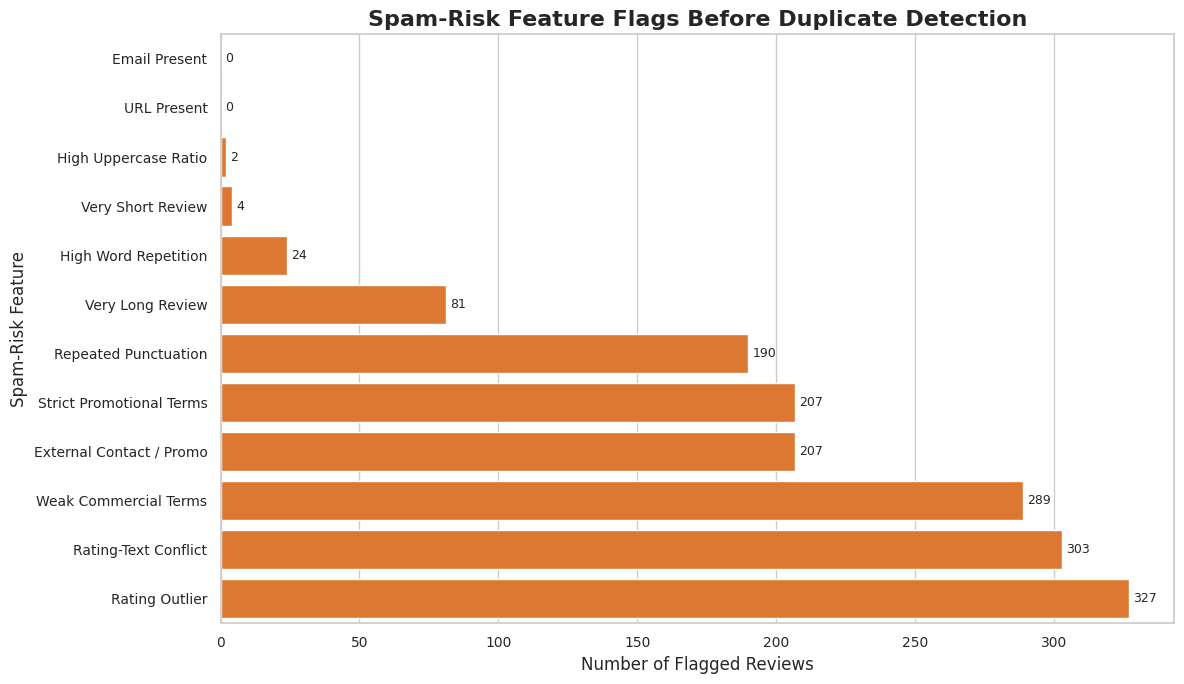

In [24]:
# ============================================================
# PHASE 2 FEATURE SUMMARY CHART
# ============================================================
# This chart shows how many reviews were flagged by each
# spam-risk feature.
# ============================================================

plot_df = phase2_feature_summary.sort_values(
    by="Flagged Reviews",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=plot_df,
    x="Flagged Reviews",
    y="Feature",
    color=MAIN_ORANGE
)

plt.title("Spam-Risk Feature Flags Before Duplicate Detection")
plt.xlabel("Number of Flagged Reviews")
plt.ylabel("Spam-Risk Feature")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/phase2_spam_feature_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 4. Phase 3: Exact Duplicate and Near-Duplicate Detection

This phase identifies exact duplicate and near-duplicate reviews.

Lecture 6 explains that duplicate and near-duplicate reviews are important indicators in opinion spam detection. Similar reviews may suggest repeated, copied, template-like, or suspicious review behaviour.

This phase uses two methods:

1. **Exact duplicate detection**  
   Reviews with identical cleaned text.

2. **Near-duplicate detection**  
   Reviews with highly similar text based on TF-IDF cosine similarity.

## Similarity Method

The cleaned review text is converted into TF-IDF features using word n-grams. Then cosine similarity is calculated between review pairs.

A review is flagged as near-duplicate if it has similarity above a selected threshold.

For this project:

```text
Near-duplicate threshold = 0.90

This means two reviews are considered near-duplicates if their text is at least 90% similar.

The result is not used as a confirmed spam label. It is used as one spam-risk signal.

In [25]:
# ============================================================
# EXACT DUPLICATE DETECTION
# ============================================================
# This cell detects exact duplicate reviews based on cleaned text.
#
# Exact duplicates can indicate repeated or copied review content.
# ============================================================

# Use machine-learning cleaned review text for duplicate checking
spam_df["duplicate_check_text"] = (
    spam_df["ml_clean_review"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Count how many times each cleaned review appears
duplicate_text_counts = spam_df["duplicate_check_text"].value_counts()

spam_df["exact_duplicate_count"] = spam_df["duplicate_check_text"].map(
    duplicate_text_counts
)

spam_df["exact_duplicate_flag"] = (
    spam_df["exact_duplicate_count"] > 1
).astype(int)

exact_duplicate_reviews = spam_df[
    spam_df["exact_duplicate_flag"] == 1
].copy()

exact_duplicate_summary = pd.DataFrame([
    {
        "Metric": "Reviews flagged as exact duplicates",
        "Value": int(spam_df["exact_duplicate_flag"].sum())
    },
    {
        "Metric": "Unique duplicated text groups",
        "Value": int((duplicate_text_counts > 1).sum())
    },
    {
        "Metric": "Maximum duplicate count for same text",
        "Value": int(duplicate_text_counts.max())
    }
])

exact_duplicate_reviews.to_csv(
    "results_notebook4/exact_duplicate_reviews.csv",
    index=False
)

exact_duplicate_summary.to_csv(
    "results_notebook4/exact_duplicate_summary.csv",
    index=False
)

print("Exact duplicate detection completed.")
display(exact_duplicate_summary)

exact_duplicate_reviews[
    [
        "review_id",
        "app",
        "rating",
        "review",
        "exact_duplicate_count"
    ]
].head(20)

Exact duplicate detection completed.


,Metric,Value
0,Reviews flagged as exact duplicates,0
1,Unique duplicated text groups,0
2,Maximum duplicate count for same text,1


,review_id,app,rating,review,exact_duplicate_count


In [26]:
# ============================================================
# PREPARE TEXT FOR NEAR-DUPLICATE DETECTION
# ============================================================
# This cell prepares cleaned review text for TF-IDF similarity.
#
# Empty or very short cleaned texts are replaced with original review text.
# ============================================================

spam_df["near_duplicate_text"] = spam_df["duplicate_check_text"].copy()

empty_text_mask = spam_df["near_duplicate_text"].str.strip().eq("")

spam_df.loc[empty_text_mask, "near_duplicate_text"] = (
    spam_df.loc[empty_text_mask, "review"]
    .astype(str)
    .str.lower()
)

print("Near-duplicate text prepared.")
print("Empty near-duplicate text rows:", spam_df["near_duplicate_text"].str.strip().eq("").sum())

spam_df[["review", "near_duplicate_text"]].head()

Near-duplicate text prepared.
Empty near-duplicate text rows: 0


,review,near_duplicate_text
0,I like WhatsApp to talk to friends that aren’t...,like whatsapp talk friend not america recently...
1,"As a mobile user, it is unfortunate that we ca...",mobile user unfortunate cannot share screen mo...
2,Does everything the desktop app does! Slight b...,everything desktop app slight bug switching wi...
3,I logged in today and my credits and history w...,logged today credit history gone number change...
4,"I’ve been using Skype for years as a gamer, an...",using skype year gamer liked mobile recent upd...


In [27]:
# ============================================================
# TF-IDF VECTORIZATION FOR NEAR-DUPLICATE DETECTION
# ============================================================
# This cell converts review text into TF-IDF vectors.
#
# ngram_range=(1, 2) captures both unigrams and bigrams.
# This follows the idea that similar review wording can be detected
# more effectively with word-level n-gram features.
# ============================================================

near_duplicate_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95
)

near_duplicate_tfidf_matrix = near_duplicate_vectorizer.fit_transform(
    spam_df["near_duplicate_text"]
)

print("TF-IDF matrix created.")
print("Shape:", near_duplicate_tfidf_matrix.shape)

TF-IDF matrix created.
Shape: (1615, 10000)


In [28]:
# ============================================================
# COMPUTE NEAR-DUPLICATE SIMILARITY PAIRS
# ============================================================
# This cell computes cosine similarity between reviews.
#
# Since the dataset has 1,615 reviews, a full similarity matrix is
# manageable.
#
# Threshold:
# - 0.90 similarity or above = near duplicate
#
# Exact same review index pairs are ignored.
# ============================================================

NEAR_DUPLICATE_THRESHOLD = 0.90

similarity_matrix = cosine_similarity(near_duplicate_tfidf_matrix)

near_duplicate_pairs = []

n_reviews = similarity_matrix.shape[0]

for i in range(n_reviews):
    for j in range(i + 1, n_reviews):
        similarity_score = similarity_matrix[i, j]

        if similarity_score >= NEAR_DUPLICATE_THRESHOLD:
            near_duplicate_pairs.append({
                "review_index_1": i,
                "review_index_2": j,
                "review_id_1": spam_df.iloc[i]["review_id"],
                "review_id_2": spam_df.iloc[j]["review_id"],
                "app_1": spam_df.iloc[i]["app"],
                "app_2": spam_df.iloc[j]["app"],
                "rating_1": spam_df.iloc[i]["rating"],
                "rating_2": spam_df.iloc[j]["rating"],
                "similarity_score": round(float(similarity_score), 4),
                "review_1": spam_df.iloc[i]["review"],
                "review_2": spam_df.iloc[j]["review"]
            })

near_duplicate_pairs_df = pd.DataFrame(near_duplicate_pairs)

near_duplicate_pairs_df.to_csv(
    "results_notebook4/near_duplicate_review_pairs.csv",
    index=False
)

print("Near-duplicate pair detection completed.")
print("Number of near-duplicate pairs:", len(near_duplicate_pairs_df))

near_duplicate_pairs_df.head(20)

Near-duplicate pair detection completed.
Number of near-duplicate pairs: 1


,review_index_1,review_index_2,review_id_1,review_id_2,app_1,app_2,rating_1,rating_2,similarity_score,review_1,review_2
0,1478,1542,ce006805-17aa-4448-928e-0860e5c56866,40e69b0e-7452-4f8b-8f4e-b129e9f58037,free-tone-calling-texting,teamspeak-3,1,2,1.0,I was tricked and i want my money back,Want my money back


In [29]:
# ============================================================
# FLAG NEAR-DUPLICATE REVIEWS
# ============================================================
# This cell marks reviews that appear in at least one near-duplicate pair.
# ============================================================

near_duplicate_review_indices = set()

if len(near_duplicate_pairs_df) > 0:
    near_duplicate_review_indices.update(
        near_duplicate_pairs_df["review_index_1"].tolist()
    )
    near_duplicate_review_indices.update(
        near_duplicate_pairs_df["review_index_2"].tolist()
    )

spam_df["near_duplicate_flag"] = 0

spam_df.loc[
    list(near_duplicate_review_indices),
    "near_duplicate_flag"
] = 1

near_duplicate_reviews = spam_df[
    spam_df["near_duplicate_flag"] == 1
].copy()

near_duplicate_reviews.to_csv(
    "results_notebook4/near_duplicate_reviews.csv",
    index=False
)

near_duplicate_summary = pd.DataFrame([
    {
        "Metric": "Near-duplicate similarity threshold",
        "Value": NEAR_DUPLICATE_THRESHOLD
    },
    {
        "Metric": "Near-duplicate pairs found",
        "Value": len(near_duplicate_pairs_df)
    },
    {
        "Metric": "Reviews flagged as near duplicates",
        "Value": int(spam_df["near_duplicate_flag"].sum())
    }
])

near_duplicate_summary.to_csv(
    "results_notebook4/near_duplicate_summary.csv",
    index=False
)

print("Near-duplicate reviews flagged.")
display(near_duplicate_summary)

near_duplicate_reviews[
    [
        "review_id",
        "app",
        "rating",
        "review"
    ]
].head(20)

Near-duplicate reviews flagged.


,Metric,Value
0,Near-duplicate similarity threshold,0.9
1,Near-duplicate pairs found,1.0
2,Reviews flagged as near duplicates,2.0


,review_id,app,rating,review
1478,ce006805-17aa-4448-928e-0860e5c56866,free-tone-calling-texting,1,I was tricked and i want my money back
1542,40e69b0e-7452-4f8b-8f4e-b129e9f58037,teamspeak-3,2,Want my money back


In [30]:
# ============================================================
# DUPLICATE RISK COMBINED FEATURE
# ============================================================
# This cell combines exact duplicate and near-duplicate signals.
# ============================================================

spam_df["duplicate_risk_flag"] = (
    (spam_df["exact_duplicate_flag"] == 1) |
    (spam_df["near_duplicate_flag"] == 1)
).astype(int)

duplicate_risk_summary = (
    spam_df["duplicate_risk_flag"]
    .value_counts()
    .reset_index()
)

duplicate_risk_summary.columns = ["Duplicate Risk Flag", "Count"]

duplicate_risk_summary["Percentage"] = (
    duplicate_risk_summary["Count"] /
    duplicate_risk_summary["Count"].sum() * 100
).round(2)

duplicate_risk_summary.to_csv(
    "results_notebook4/duplicate_risk_summary.csv",
    index=False
)

print("Duplicate risk feature created.")
display(duplicate_risk_summary)

Duplicate risk feature created.


,Duplicate Risk Flag,Count,Percentage
0,0,1613,99.88
1,1,2,0.12


In [31]:
# ============================================================
# DUPLICATE RISK BY APP
# ============================================================
# This table shows which apps contain more duplicate-risk reviews.
# ============================================================

duplicate_risk_by_app = (
    spam_df
    .groupby("app")
    .agg(
        total_reviews=("review_id", "count"),
        duplicate_risk_reviews=("duplicate_risk_flag", "sum"),
        exact_duplicate_reviews=("exact_duplicate_flag", "sum"),
        near_duplicate_reviews=("near_duplicate_flag", "sum")
    )
    .reset_index()
)

duplicate_risk_by_app["duplicate_risk_percentage"] = (
    duplicate_risk_by_app["duplicate_risk_reviews"] /
    duplicate_risk_by_app["total_reviews"] * 100
).round(2)

duplicate_risk_by_app = duplicate_risk_by_app.sort_values(
    by="duplicate_risk_percentage",
    ascending=False
)

duplicate_risk_by_app.to_csv(
    "results_notebook4/duplicate_risk_by_app.csv",
    index=False
)

duplicate_risk_by_app

,app,total_reviews,duplicate_risk_reviews,exact_duplicate_reviews,near_duplicate_reviews,duplicate_risk_percentage
3,teamspeak-3,234,1,0,1,0.43
2,free-tone-calling-texting,471,1,0,1,0.21
1,facebook,271,0,0,0,0.00
0,discord,272,0,0,0,0.00
4,threema-the-secure-messenger,94,0,0,0,0.00
5,whatsapp-messenger,273,0,0,0,0.00


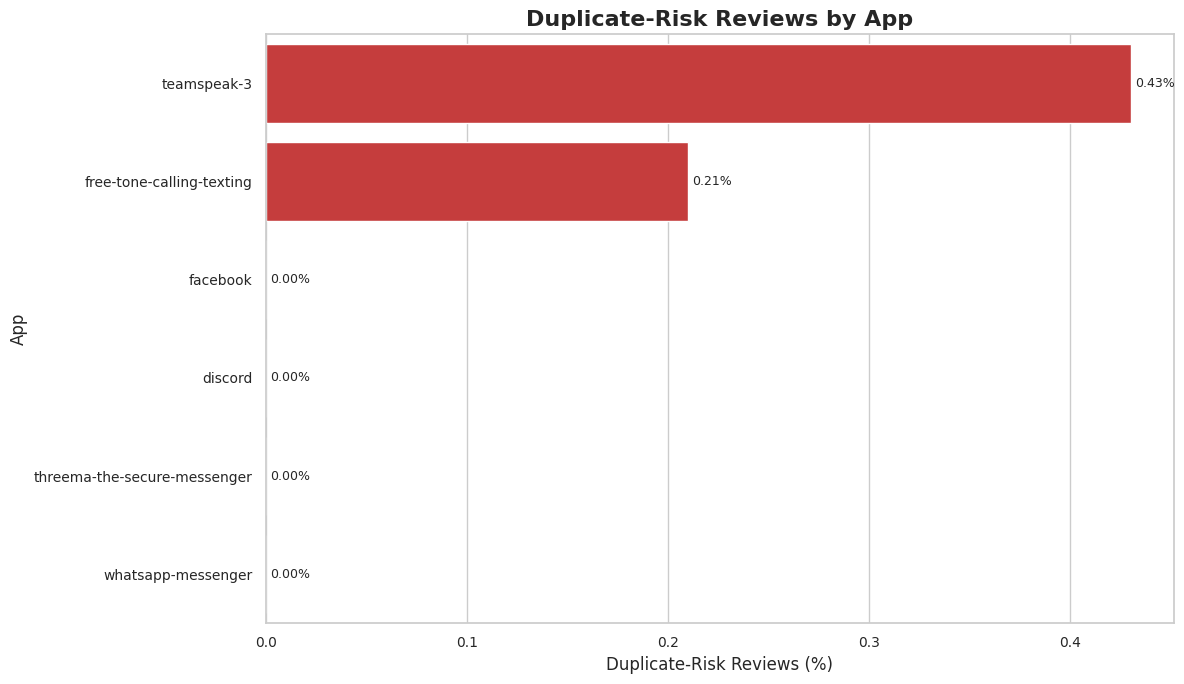

In [32]:
# ============================================================
# DUPLICATE RISK BY APP CHART
# ============================================================
# This chart shows duplicate-risk percentage by app.
# ============================================================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=duplicate_risk_by_app,
    x="duplicate_risk_percentage",
    y="app",
    color=MAIN_RED
)

plt.title("Duplicate-Risk Reviews by App")
plt.xlabel("Duplicate-Risk Reviews (%)")
plt.ylabel("App")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/duplicate_risk_by_app.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [33]:
# ============================================================
# SAVE PHASE 3 DATASET
# ============================================================
# This saves the spam dataframe after duplicate detection.
# ============================================================

spam_df.to_csv(
    "results_notebook4/spam_risk_features_phase3_with_duplicates.csv",
    index=False
)

print("Phase 3 spam-risk dataset saved.")
print("Shape:", spam_df.shape)

Phase 3 spam-risk dataset saved.
Shape: (1615, 37)


# 5. Phase 4: Spam-Risk Scoring

This phase combines the spam-risk indicators into one final spam-risk score.

Since the dataset does not contain manually verified spam labels, this notebook does not claim to classify reviews as confirmed spam. Instead, it assigns a **spam-risk level** based on multiple suspicious signals.

## Spam-Risk Signals Used

| Signal | Reason |
|---|---|
| Duplicate risk | Duplicate or near-duplicate reviews may indicate copied content |
| Very short review | Very short reviews may be generic or low-information |
| Very long review | Extremely long reviews may be unusual or off-topic |
| High uppercase ratio | Excessive capitalization may indicate exaggerated or promotional text |
| Repeated punctuation | Repeated `!!!` or `???` may indicate exaggerated writing |
| External contact / promotional pattern | URLs, emails, or promotional words may indicate advertisement-like content |
| High word repetition | Repeated wording may indicate low-quality or template-like writing |
| Rating outlier | Rating strongly deviates from the app average |
| Rating-text conflict | Rating sentiment conflicts with the review text sentiment |

## Risk Score Interpretation

| Spam-Risk Score | Risk Level |
|---|---|
| 0–1 | Low Risk |
| 2–3 | Medium Risk |
| 4 or above | High Risk |

The risk score is used for analysis and manual review, not automatic deletion.

In [34]:
# ============================================================
# DEFINE WEIGHTED SPAM-RISK SCORE
# ============================================================
# This cell combines spam-risk signals into a weighted score.
#
# Stronger indicators receive higher weight:
# - Duplicate risk
# - Rating-text conflict
# - External promotional/contact pattern
#
# Weaker indicators receive lower weight:
# - Repeated punctuation
# - Very short/long review
# - High uppercase
# - High repetition
# ============================================================

spam_df["spam_risk_score"] = 0

# Strong spam-risk signals
spam_df["spam_risk_score"] += spam_df["duplicate_risk_flag"] * 3
spam_df["spam_risk_score"] += spam_df["rating_text_conflict_flag"] * 2
spam_df["spam_risk_score"] += spam_df["external_contact_or_promo_flag"] * 2

# Medium spam-risk signals
spam_df["spam_risk_score"] += spam_df["rating_outlier_flag"] * 1
spam_df["spam_risk_score"] += spam_df["high_repetition_flag"] * 1

# Lower-level writing style signals
spam_df["spam_risk_score"] += spam_df["very_short_review_flag"] * 1
spam_df["spam_risk_score"] += spam_df["very_long_review_flag"] * 1
spam_df["spam_risk_score"] += spam_df["high_uppercase_flag"] * 1
spam_df["spam_risk_score"] += spam_df["repeated_punctuation_flag"] * 1

print("Weighted spam-risk score created.")

spam_df[
    [
        "review_id",
        "app",
        "rating",
        "review",
        "spam_risk_score"
    ]
].head()

Weighted spam-risk score created.


,review_id,app,rating,review,spam_risk_score
0,aa65ef9e-27c0-496e-be43-089c1b186ff9,whatsapp-messenger,4,I like WhatsApp to talk to friends that aren’t...,0
1,fb8b4293-2956-446e-9181-02ed3ceff8ac,discord,4,"As a mobile user, it is unfortunate that we ca...",0
2,b9c54729-6dea-44da-877e-f1891cf977c6,teamspeak-3,5,Does everything the desktop app does! Slight b...,1
3,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,free-tone-calling-texting,1,I logged in today and my credits and history w...,1
4,86ed17e1-571f-47ba-b405-d2b7991a3a42,discord,5,"I’ve been using Skype for years as a gamer, an...",0


In [35]:
# ============================================================
# ASSIGN SPAM-RISK LEVEL
# ============================================================
# This cell converts the numerical spam-risk score into:
# - Low Risk
# - Medium Risk
# - High Risk
# ============================================================

def assign_spam_risk_level(score):
    if score >= 4:
        return "High Risk"
    elif score >= 2:
        return "Medium Risk"
    else:
        return "Low Risk"


spam_df["spam_risk_level"] = spam_df["spam_risk_score"].apply(
    assign_spam_risk_level
)

spam_risk_level_summary = (
    spam_df["spam_risk_level"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .reset_index()
)

spam_risk_level_summary.columns = ["Spam Risk Level", "Count"]

spam_risk_level_summary["Percentage"] = (
    spam_risk_level_summary["Count"] /
    spam_risk_level_summary["Count"].sum() * 100
).round(2)

spam_risk_level_summary.to_csv(
    "results_notebook4/spam_risk_level_summary.csv",
    index=False
)

spam_risk_level_summary

,Spam Risk Level,Count,Percentage
0,Low Risk,1094,67.74
1,Medium Risk,435,26.93
2,High Risk,86,5.33


In [36]:
# ============================================================
# SPAM-RISK SCORE DISTRIBUTION
# ============================================================
# This table shows how many reviews have each spam-risk score.
# ============================================================

spam_risk_score_distribution = (
    spam_df["spam_risk_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

spam_risk_score_distribution.columns = ["Spam Risk Score", "Count"]

spam_risk_score_distribution["Percentage"] = (
    spam_risk_score_distribution["Count"] /
    spam_risk_score_distribution["Count"].sum() * 100
).round(2)

spam_risk_score_distribution.to_csv(
    "results_notebook4/spam_risk_score_distribution.csv",
    index=False
)

spam_risk_score_distribution

,Spam Risk Score,Count,Percentage
0,0,803,49.72
1,1,291,18.02
2,2,317,19.63
3,3,118,7.31
4,4,60,3.72
5,5,22,1.36
6,6,3,0.19
7,7,1,0.06


In [37]:
# ============================================================
# SPAM-RISK REASON SUMMARY
# ============================================================
# This cell creates readable reasons for why a review was flagged.
#
# Refinement:
# - Weak commercial terms are shown as contextual information only.
# - They are not treated as a strong spam-risk reason unless combined
#   with stronger signals.
#
# Assignment usage:
# - Useful for report explanation
# - Useful later for Streamlit app spam-risk detector
# ============================================================

def get_spam_risk_reasons(row):
    reasons = []

    if row["duplicate_risk_flag"] == 1:
        reasons.append("duplicate or near-duplicate text")

    if row["rating_text_conflict_flag"] == 1:
        reasons.append("rating-text sentiment conflict")

    if row["external_contact_or_promo_flag"] == 1:
        reasons.append("strict external promotional/contact signal")

    if row["rating_outlier_flag"] == 1:
        reasons.append("rating strongly deviates from app average")

    if row["high_repetition_flag"] == 1:
        reasons.append("high word repetition")

    if row["very_short_review_flag"] == 1:
        reasons.append("very short review")

    if row["very_long_review_flag"] == 1:
        reasons.append("very long review")

    if row["high_uppercase_flag"] == 1:
        reasons.append("high uppercase ratio")

    if row["repeated_punctuation_flag"] == 1:
        reasons.append("repeated punctuation")

    # Weak commercial terms are not strong spam evidence alone.
    if (
        row["weak_commercial_terms_flag"] == 1 and
        len(reasons) > 0
    ):
        reasons.append("weak commercial app-review terms present")

    if len(reasons) == 0:
        return "No major spam-risk signals detected"

    return "; ".join(reasons)


spam_df["spam_risk_reasons"] = spam_df.apply(
    get_spam_risk_reasons,
    axis=1
)

spam_df[
    [
        "review",
        "rating",
        "spam_risk_score",
        "spam_risk_level",
        "spam_risk_reasons"
    ]
].head(10)

,review,rating,spam_risk_score,spam_risk_level,spam_risk_reasons
0,I like WhatsApp to talk to friends that aren’t...,4,0,Low Risk,No major spam-risk signals detected
1,"As a mobile user, it is unfortunate that we ca...",4,0,Low Risk,No major spam-risk signals detected
2,Does everything the desktop app does! Slight b...,5,1,Low Risk,rating strongly deviates from app average
3,I logged in today and my credits and history w...,1,1,Low Risk,rating strongly deviates from app average; wea...
4,"I’ve been using Skype for years as a gamer, an...",5,0,Low Risk,No major spam-risk signals detected
5,Facebook had become basically unusable for mon...,1,4,High Risk,strict external promotional/contact signal; ra...
6,I’ve been using WhatsApp for five years now. I...,4,2,Medium Risk,rating-text sentiment conflict
7,I love this app. Everyone in my family uses it...,1,3,Medium Risk,rating-text sentiment conflict; rating strongl...
8,I mean comparing to telegram it lacks some fun...,3,0,Low Risk,No major spam-risk signals detected
9,Works wonderfully. Offer an option to turn off...,4,2,Medium Risk,rating-text sentiment conflict; weak commercia...


In [38]:
# ============================================================
# POTENTIAL SPAM REVIEWS TABLE
# ============================================================
# This table extracts reviews categorized as High Risk.
#
# Important:
# These are not confirmed spam. They are reviews that require
# manual checking due to multiple suspicious signals.
# ============================================================

potential_spam_reviews = spam_df[
    spam_df["spam_risk_level"] == "High Risk"
].copy()

potential_spam_reviews = potential_spam_reviews.sort_values(
    by="spam_risk_score",
    ascending=False
)

potential_spam_reviews.to_csv(
    "results_notebook4/potential_spam_reviews_high_risk.csv",
    index=False
)

print("Potential high-risk spam reviews:")
print("Count:", len(potential_spam_reviews))

potential_spam_reviews[
    [
        "review_id",
        "app",
        "rating",
        "rating_sentiment",
        "lexicon_text_sentiment",
        "review",
        "spam_risk_score",
        "spam_risk_level",
        "spam_risk_reasons"
    ]
].head(20)

Potential high-risk spam reviews:
Count: 86


,review_id,app,rating,rating_sentiment,lexicon_text_sentiment,review,spam_risk_score,spam_risk_level,spam_risk_reasons
639,100b8d8c-915f-4281-873d-98b25ca0a760,free-tone-calling-texting,1,Negative,Positive,Unbelievable!!!This is just another front door...,7,High Risk,rating-text sentiment conflict; strict externa...
63,ae6dda2b-b671-4053-b9c5-1fb9a43d9f66,facebook,1,Negative,Positive,I never really cared for social media. I think...,6,High Risk,rating-text sentiment conflict; strict externa...
666,106d03f6-01e9-4578-8189-83903e2c7096,facebook,1,Negative,Positive,Nobody wants a game page or a group page. It’s...,6,High Risk,rating-text sentiment conflict; strict externa...
1437,d99fa145-a150-492e-94f9-586a9220e854,discord,2,Negative,Positive,"Okay so the problem isn’t with how Discord is,...",6,High Risk,rating-text sentiment conflict; strict externa...
29,e196722b-f977-4c3b-9241-e16633f0e91b,facebook,1,Negative,Neutral,Facebook used to be a fun place to connect wit...,5,High Risk,strict external promotional/contact signal; ra...
11,526921cd-7a56-4760-af00-9ec1c417a0e4,free-tone-calling-texting,1,Negative,Positive,I open this app. Ads. I payed for the minutes....,5,High Risk,rating-text sentiment conflict; strict externa...
303,e72446e9-d33b-4753-935e-d0f891566d1f,discord,2,Negative,Positive,Out of all of the social media platforms I’ve ...,5,High Risk,rating-text sentiment conflict; strict externa...
1035,4396341f-40c9-47a2-9225-5949263a561a,discord,1,Negative,Negative,"Dear discord,Right now I’m extremely mad and f...",5,High Risk,strict external promotional/contact signal; ra...
687,a5b7185f-34af-451e-bbb3-fa1ff2f2a498,facebook,4,Positive,Negative,"In the latest update, the app no longer has th...",5,High Risk,rating-text sentiment conflict; strict externa...
760,af254e30-a19d-41ee-8b15-a778895cd2e3,free-tone-calling-texting,4,Positive,Negative,This app is a miracle!!! I️ love it but one pr...,5,High Risk,rating-text sentiment conflict; strict externa...


In [39]:
# ============================================================
# MEDIUM AND HIGH RISK REVIEWS TABLE
# ============================================================
# This table saves all reviews that are not Low Risk.
# These reviews can be manually inspected if needed.
# ============================================================

medium_high_risk_reviews = spam_df[
    spam_df["spam_risk_level"].isin(["Medium Risk", "High Risk"])
].copy()

medium_high_risk_reviews = medium_high_risk_reviews.sort_values(
    by="spam_risk_score",
    ascending=False
)

medium_high_risk_reviews.to_csv(
    "results_notebook4/medium_high_spam_risk_reviews.csv",
    index=False
)

print("Medium + High risk reviews:")
print("Count:", len(medium_high_risk_reviews))

medium_high_risk_reviews[
    [
        "review_id",
        "app",
        "rating",
        "review",
        "spam_risk_score",
        "spam_risk_level",
        "spam_risk_reasons"
    ]
].head(20)

Medium + High risk reviews:
Count: 521


,review_id,app,rating,review,spam_risk_score,spam_risk_level,spam_risk_reasons
639,100b8d8c-915f-4281-873d-98b25ca0a760,free-tone-calling-texting,1,Unbelievable!!!This is just another front door...,7,High Risk,rating-text sentiment conflict; strict externa...
63,ae6dda2b-b671-4053-b9c5-1fb9a43d9f66,facebook,1,I never really cared for social media. I think...,6,High Risk,rating-text sentiment conflict; strict externa...
666,106d03f6-01e9-4578-8189-83903e2c7096,facebook,1,Nobody wants a game page or a group page. It’s...,6,High Risk,rating-text sentiment conflict; strict externa...
1437,d99fa145-a150-492e-94f9-586a9220e854,discord,2,"Okay so the problem isn’t with how Discord is,...",6,High Risk,rating-text sentiment conflict; strict externa...
1242,7358473e-e7f0-4eb1-93aa-7a1560537de9,whatsapp-messenger,5,Upgraded to ios11; have made all the Whatsapp ...,5,High Risk,rating-text sentiment conflict; strict externa...
83,61b89cda-dd07-4857-82c6-87dd4f347762,discord,1,"Okay, so I don’t usually write negative review...",5,High Risk,rating-text sentiment conflict; strict externa...
957,8622e0f4-558c-4b63-8576-7e7f0bc1260d,facebook,1,Facebook used to be a great place to reconnect...,5,High Risk,rating-text sentiment conflict; rating strongl...
942,5b2dabc5-2aae-4812-b0b3-a92c6aec544e,facebook,4,Update: a few days after this review Facebook ...,5,High Risk,rating-text sentiment conflict; strict externa...
645,80a88380-f91a-45df-a205-89c7d65f3903,facebook,4,I'm disappointed in the options for notificati...,5,High Risk,rating-text sentiment conflict; strict externa...
240,db90fd74-2ff3-4838-9bc5-3ce5cbdd4f1c,facebook,5,I haven’t been able to see anything about my a...,5,High Risk,rating-text sentiment conflict; strict externa...


In [40]:
# ============================================================
# SPAM-CLEANED REVIEW DATASET
# ============================================================
# This cell creates a conservative spam-cleaned dataset by removing
# only High Risk reviews.
#
# Medium Risk reviews are kept because they may still be valid reviews.
#
# This cleaned dataset is optional and is not used to replace the
# original modelling dataset unless manually approved.
# ============================================================

spam_cleaned_review_df = spam_df[
    spam_df["spam_risk_level"] != "High Risk"
].copy()

spam_cleaned_review_df.to_csv(
    "results_notebook4/spam_cleaned_review_level_dataset.csv",
    index=False
)

print("Original review dataset size:", len(spam_df))
print("Spam-cleaned dataset size:", len(spam_cleaned_review_df))
print("High-risk reviews removed:", len(spam_df) - len(spam_cleaned_review_df))

Original review dataset size: 1615
Spam-cleaned dataset size: 1529
High-risk reviews removed: 86


In [41]:
# ============================================================
# SPAM-RISK BY APP
# ============================================================
# This table summarizes spam-risk levels by app.
# ============================================================

spam_risk_by_app = pd.crosstab(
    spam_df["app"],
    spam_df["spam_risk_level"]
)

# Ensure all columns exist
for col in ["Low Risk", "Medium Risk", "High Risk"]:
    if col not in spam_risk_by_app.columns:
        spam_risk_by_app[col] = 0

spam_risk_by_app = spam_risk_by_app[
    ["Low Risk", "Medium Risk", "High Risk"]
]

spam_risk_by_app["Total Reviews"] = spam_risk_by_app.sum(axis=1)

spam_risk_by_app["High Risk Percentage"] = (
    spam_risk_by_app["High Risk"] /
    spam_risk_by_app["Total Reviews"] * 100
).round(2)

spam_risk_by_app = spam_risk_by_app.sort_values(
    by="High Risk Percentage",
    ascending=False
)

spam_risk_by_app.to_csv(
    "results_notebook4/spam_risk_by_app.csv"
)

spam_risk_by_app

spam_risk_level,Low Risk,Medium Risk,High Risk,Total Reviews,High Risk Percentage
app,,,,,
facebook,110,119,42,271,15.50
discord,160,95,17,272,6.25
whatsapp-messenger,203,61,9,273,3.30
free-tone-calling-texting,357,101,13,471,2.76
threema-the-secure-messenger,75,17,2,94,2.13
teamspeak-3,189,42,3,234,1.28


# 6. Phase 5: Spam-Risk Visualization and Analysis

This phase visualizes and analyses the opinion spam-risk results.

The goal is to understand:

1. How many reviews are Low, Medium, and High Risk
2. Which apps contain more high-risk reviews
3. Which spam-risk features contribute most often
4. Whether rating-text conflict is a major spam-risk factor
5. What types of reviews are flagged for manual inspection

Important note:

The reviews identified as High Risk are not automatically confirmed as spam. They are reviews that contain multiple suspicious signals and should be manually checked before removal.

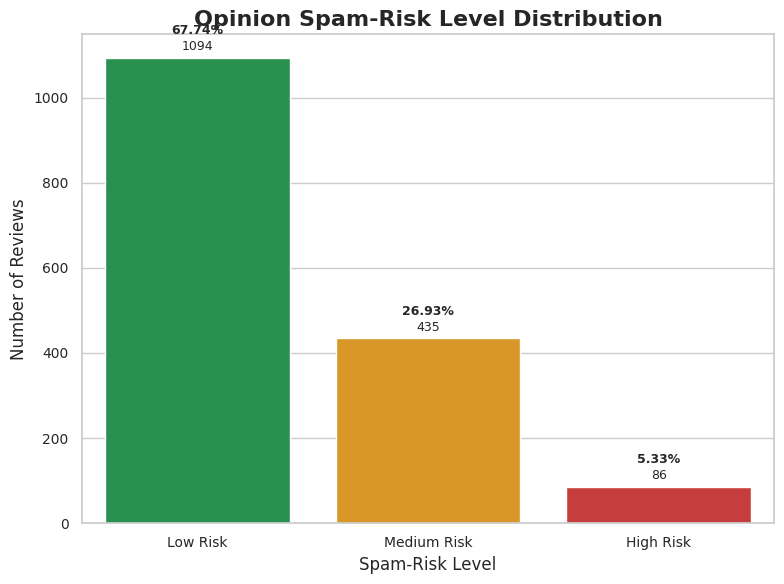

In [42]:
# ============================================================
# SPAM-RISK LEVEL DISTRIBUTION CHART
# ============================================================
# This chart shows the number of reviews in each spam-risk level.
#
# Assignment usage:
# - Main visual for opinion spam detection section
# ============================================================

plt.figure(figsize=(8, 6))

risk_order = ["Low Risk", "Medium Risk", "High Risk"]

plot_df = spam_risk_level_summary.copy()
plot_df["Spam Risk Level"] = pd.Categorical(
    plot_df["Spam Risk Level"],
    categories=risk_order,
    ordered=True
)
plot_df = plot_df.sort_values("Spam Risk Level")

risk_palette = [
    SPAM_RISK_COLORS[level]
    for level in plot_df["Spam Risk Level"]
]

ax = sns.barplot(
    data=plot_df,
    x="Spam Risk Level",
    y="Count",
    palette=risk_palette
)

plt.title("Opinion Spam-Risk Level Distribution")
plt.xlabel("Spam-Risk Level")
plt.ylabel("Number of Reviews")

add_bar_labels(ax)

for i, row in plot_df.iterrows():
    ax.text(
        risk_order.index(row["Spam Risk Level"]),
        row["Count"] + plot_df["Count"].max() * 0.05,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/spam_risk_level_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

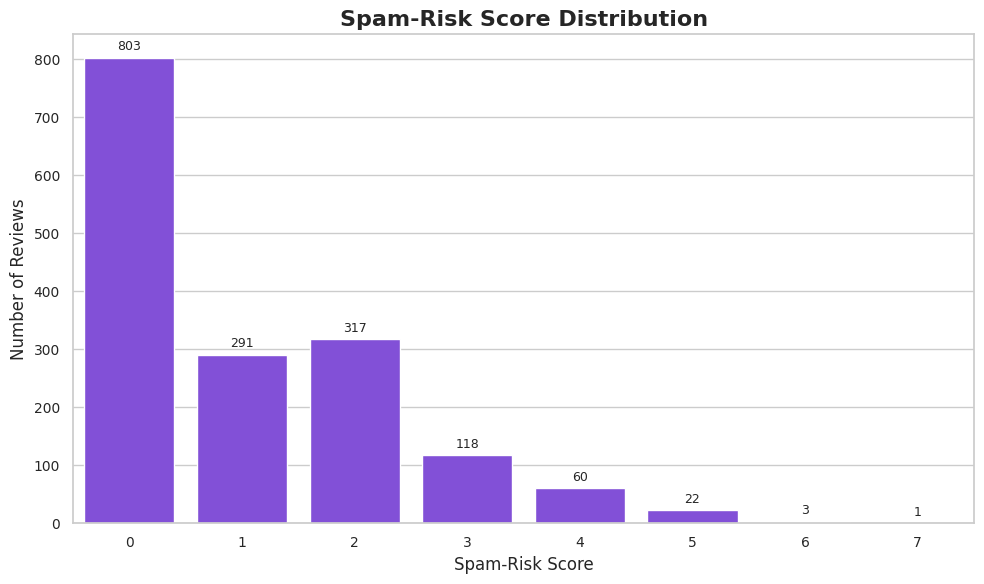

In [43]:
# ============================================================
# SPAM-RISK SCORE DISTRIBUTION CHART
# ============================================================
# This chart shows how spam-risk scores are distributed.
#
# Assignment usage:
# - Shows that most reviews have low scores
# - Helps justify the High Risk threshold
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=spam_risk_score_distribution,
    x="Spam Risk Score",
    y="Count",
    color=MAIN_PURPLE
)

plt.title("Spam-Risk Score Distribution")
plt.xlabel("Spam-Risk Score")
plt.ylabel("Number of Reviews")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/spam_risk_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

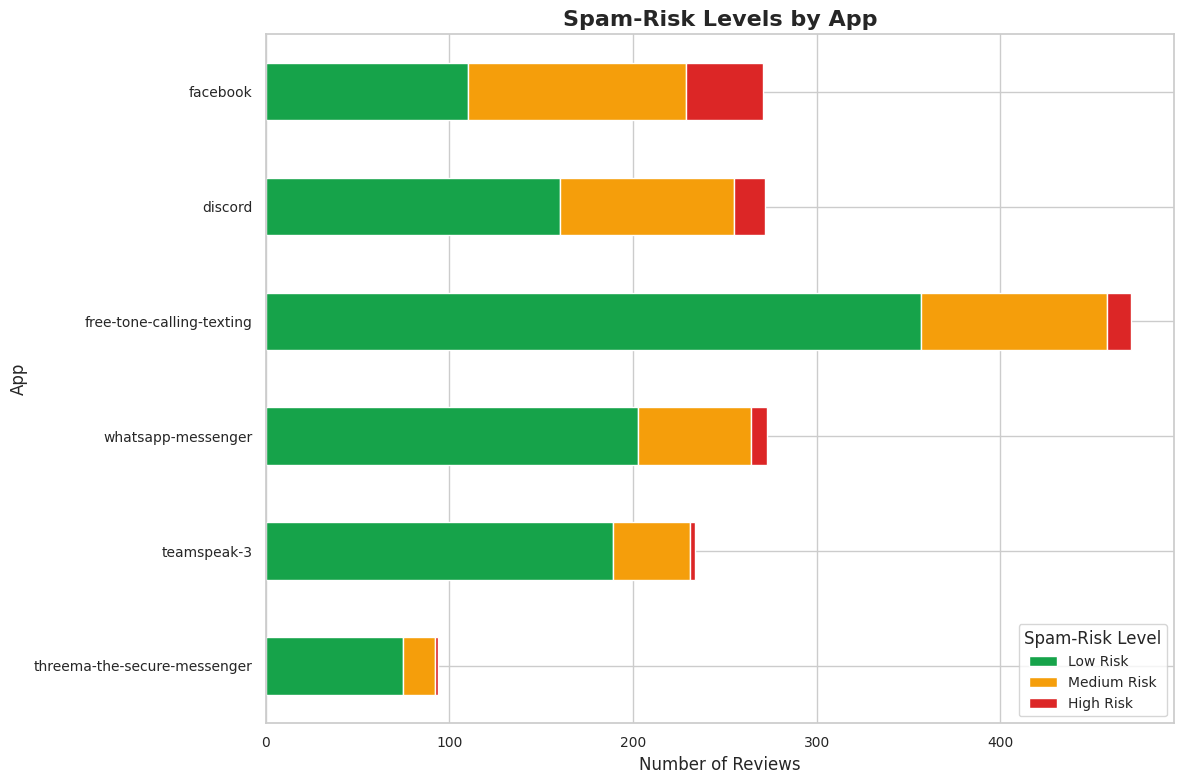

In [44]:
# ============================================================
# SPAM-RISK BY APP CHART
# ============================================================
# This stacked bar chart shows Low, Medium, and High Risk reviews
# for each app.
#
# Assignment usage:
# - Useful for comparing app-level spam-risk patterns
# ============================================================

app_risk_plot_df = spam_risk_by_app[
    ["Low Risk", "Medium Risk", "High Risk"]
].copy()

app_risk_plot_df = app_risk_plot_df.sort_values(
    by="High Risk",
    ascending=True
)

app_risk_plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8),
    color=[
        SPAM_RISK_COLORS["Low Risk"],
        SPAM_RISK_COLORS["Medium Risk"],
        SPAM_RISK_COLORS["High Risk"]
    ]
)

plt.title("Spam-Risk Levels by App")
plt.xlabel("Number of Reviews")
plt.ylabel("App")
plt.legend(title="Spam-Risk Level", loc="lower right")

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/spam_risk_levels_by_app.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

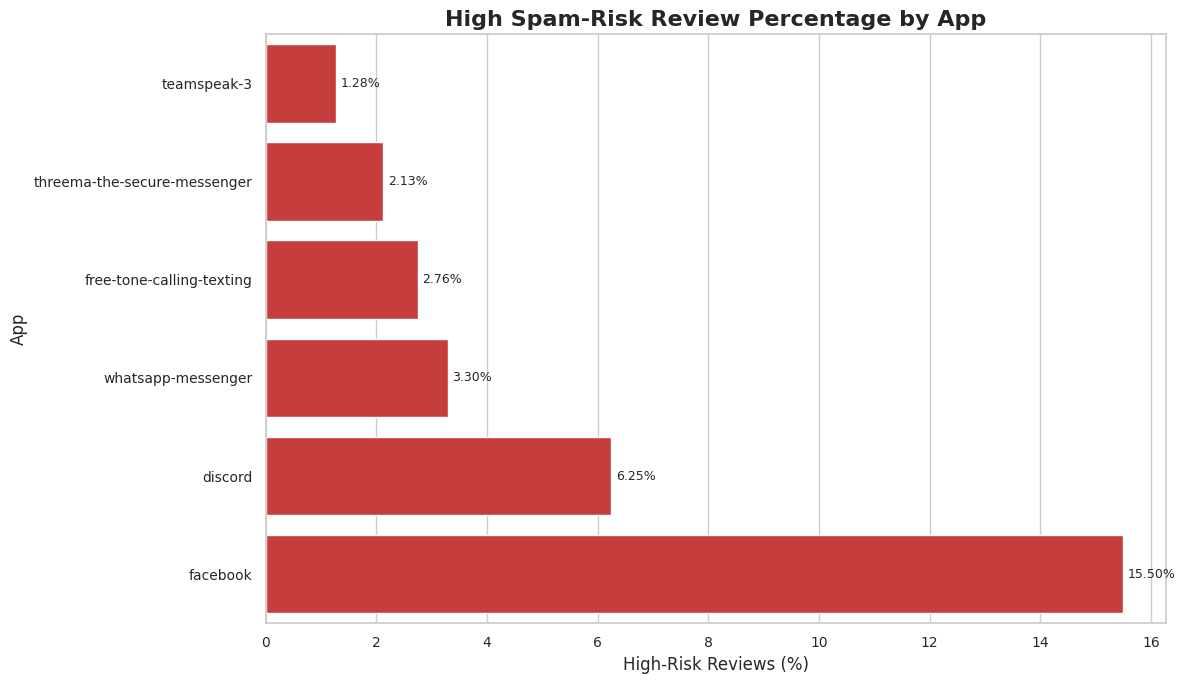

In [45]:
# ============================================================
# HIGH-RISK PERCENTAGE BY APP CHART
# ============================================================
# This chart shows which apps have the highest percentage of
# high-risk reviews.
#
# Assignment usage:
# - Strong report visual for spam-risk discussion
# ============================================================

high_risk_app_plot_df = spam_risk_by_app.reset_index().sort_values(
    by="High Risk Percentage",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=high_risk_app_plot_df,
    x="High Risk Percentage",
    y="app",
    color=MAIN_RED
)

plt.title("High Spam-Risk Review Percentage by App")
plt.xlabel("High-Risk Reviews (%)")
plt.ylabel("App")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/high_spam_risk_percentage_by_app.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [46]:
# ============================================================
# SPAM-RISK FEATURE CONTRIBUTION TABLE
# ============================================================
# This table counts how often each spam-risk feature appears
# among all reviews and among High Risk reviews.
#
# Refinement:
# Weak commercial terms are included for transparency, but they are
# not used as a direct strong spam-risk scoring feature.
# ============================================================

feature_columns = {
    "Duplicate Risk": "duplicate_risk_flag",
    "Very Short Review": "very_short_review_flag",
    "Very Long Review": "very_long_review_flag",
    "High Uppercase Ratio": "high_uppercase_flag",
    "Repeated Punctuation": "repeated_punctuation_flag",
    "Strict External Promo / Contact": "external_contact_or_promo_flag",
    "Weak Commercial Terms": "weak_commercial_terms_flag",
    "High Word Repetition": "high_repetition_flag",
    "Rating Outlier": "rating_outlier_flag",
    "Rating-Text Conflict": "rating_text_conflict_flag"
}

feature_contribution_rows = []

high_risk_df = spam_df[spam_df["spam_risk_level"] == "High Risk"].copy()

for feature_name, column_name in feature_columns.items():
    all_count = int(spam_df[column_name].sum())
    high_risk_count = int(high_risk_df[column_name].sum())

    feature_contribution_rows.append({
        "Feature": feature_name,
        "Flagged in All Reviews": all_count,
        "All Reviews Percentage": round(all_count / len(spam_df) * 100, 2),
        "Flagged in High Risk Reviews": high_risk_count,
        "High Risk Reviews Percentage": round(
            high_risk_count / len(high_risk_df) * 100,
            2
        ) if len(high_risk_df) > 0 else 0
    })

spam_feature_contribution = pd.DataFrame(feature_contribution_rows)

spam_feature_contribution = spam_feature_contribution.sort_values(
    by="Flagged in High Risk Reviews",
    ascending=False
)

spam_feature_contribution.to_csv(
    "results_notebook4/spam_feature_contribution.csv",
    index=False
)

spam_feature_contribution

,Feature,Flagged in All Reviews,All Reviews Percentage,Flagged in High Risk Reviews,High Risk Reviews Percentage
5,Strict External Promo / Contact,207,12.82,72,83.72
9,Rating-Text Conflict,303,18.76,58,67.44
8,Rating Outlier,327,20.25,44,51.16
4,Repeated Punctuation,190,11.76,29,33.72
2,Very Long Review,81,5.02,28,32.56
6,Weak Commercial Terms,289,17.89,18,20.93
7,High Word Repetition,24,1.49,7,8.14
0,Duplicate Risk,2,0.12,2,2.33
1,Very Short Review,4,0.25,1,1.16
3,High Uppercase Ratio,2,0.12,0,0.00


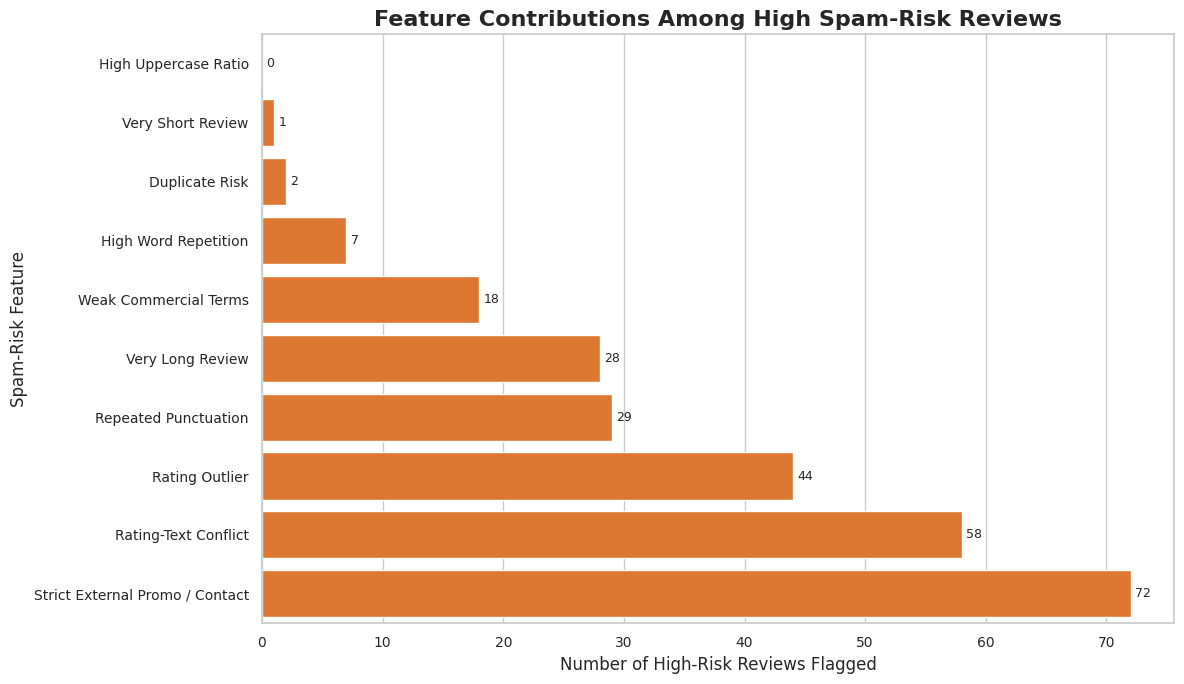

In [47]:
# ============================================================
# SPAM-RISK FEATURE CONTRIBUTION CHART
# ============================================================
# This chart shows which features are most common among
# High Risk reviews.
#
# Assignment usage:
# - Explains the spam-risk scoring outcome
# ============================================================

plot_df = spam_feature_contribution.sort_values(
    by="Flagged in High Risk Reviews",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=plot_df,
    x="Flagged in High Risk Reviews",
    y="Feature",
    color=MAIN_ORANGE
)

plt.title("Feature Contributions Among High Spam-Risk Reviews")
plt.xlabel("Number of High-Risk Reviews Flagged")
plt.ylabel("Spam-Risk Feature")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/spam_feature_contribution_high_risk.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [48]:
# ============================================================
# RATING-TEXT CONFLICT BY SPAM-RISK LEVEL
# ============================================================
# This table checks whether rating-text conflict appears more
# often in Medium/High Risk reviews.
# ============================================================

rating_conflict_by_risk = pd.crosstab(
    spam_df["spam_risk_level"],
    spam_df["rating_text_conflict_flag"]
)

rating_conflict_by_risk = rating_conflict_by_risk.reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

rating_conflict_by_risk.columns = [
    "No Rating-Text Conflict",
    "Rating-Text Conflict"
]

rating_conflict_by_risk["Total"] = rating_conflict_by_risk.sum(axis=1)

rating_conflict_by_risk["Conflict Percentage"] = (
    rating_conflict_by_risk["Rating-Text Conflict"] /
    rating_conflict_by_risk["Total"] * 100
).round(2)

rating_conflict_by_risk.to_csv(
    "results_notebook4/rating_text_conflict_by_spam_risk.csv"
)

rating_conflict_by_risk

,No Rating-Text Conflict,Rating-Text Conflict,Total,Conflict Percentage
spam_risk_level,,,,
Low Risk,1094,0,1094,0.00
Medium Risk,190,245,435,56.32
High Risk,28,58,86,67.44


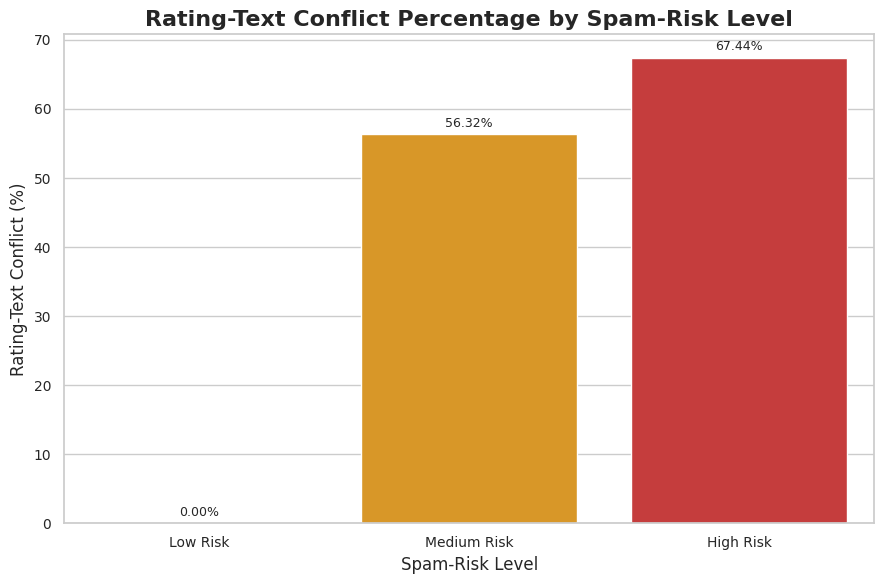

In [49]:
# ============================================================
# RATING-TEXT CONFLICT BY SPAM-RISK CHART
# ============================================================
# This chart shows rating-text conflict percentage by spam-risk level.
# ============================================================

conflict_plot_df = rating_conflict_by_risk.reset_index()

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=conflict_plot_df,
    x="spam_risk_level",
    y="Conflict Percentage",
    palette=[
        SPAM_RISK_COLORS["Low Risk"],
        SPAM_RISK_COLORS["Medium Risk"],
        SPAM_RISK_COLORS["High Risk"]
    ]
)

plt.title("Rating-Text Conflict Percentage by Spam-Risk Level")
plt.xlabel("Spam-Risk Level")
plt.ylabel("Rating-Text Conflict (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(
    "visualizations_notebook4/rating_text_conflict_by_spam_risk.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [50]:
# ============================================================
# HIGH-RISK REVIEW EXAMPLES FOR REPORT
# ============================================================
# This cell selects a small set of High Risk reviews for report
# explanation and manual review.
#
# Important:
# These are potential spam-risk examples, not confirmed spam.
# ============================================================

high_risk_examples_for_report = potential_spam_reviews[
    [
        "app",
        "rating",
        "rating_sentiment",
        "lexicon_text_sentiment",
        "review",
        "spam_risk_score",
        "spam_risk_reasons"
    ]
].head(15).copy()

high_risk_examples_for_report.to_csv(
    "results_notebook4/high_risk_examples_for_report.csv",
    index=False
)

high_risk_examples_for_report

,app,rating,rating_sentiment,lexicon_text_sentiment,review,spam_risk_score,spam_risk_reasons
639,free-tone-calling-texting,1,Negative,Positive,Unbelievable!!!This is just another front door...,7,rating-text sentiment conflict; strict externa...
63,facebook,1,Negative,Positive,I never really cared for social media. I think...,6,rating-text sentiment conflict; strict externa...
666,facebook,1,Negative,Positive,Nobody wants a game page or a group page. It’s...,6,rating-text sentiment conflict; strict externa...
1437,discord,2,Negative,Positive,"Okay so the problem isn’t with how Discord is,...",6,rating-text sentiment conflict; strict externa...
29,facebook,1,Negative,Neutral,Facebook used to be a fun place to connect wit...,5,strict external promotional/contact signal; ra...
11,free-tone-calling-texting,1,Negative,Positive,I open this app. Ads. I payed for the minutes....,5,rating-text sentiment conflict; strict externa...
303,discord,2,Negative,Positive,Out of all of the social media platforms I’ve ...,5,rating-text sentiment conflict; strict externa...
1035,discord,1,Negative,Negative,"Dear discord,Right now I’m extremely mad and f...",5,strict external promotional/contact signal; ra...
687,facebook,4,Positive,Negative,"In the latest update, the app no longer has th...",5,rating-text sentiment conflict; strict externa...
760,free-tone-calling-texting,4,Positive,Negative,This app is a miracle!!! I️ love it but one pr...,5,rating-text sentiment conflict; strict externa...


In [51]:
# ============================================================
# SPAM-RISK INTERPRETATION NOTES
# ============================================================
# This cell creates report-ready interpretation notes.
# ============================================================

spam_risk_interpretation_notes = pd.DataFrame([
    {
        "Finding": "Most reviews are low or medium risk",
        "Interpretation": (
            "The dataset does not show strong evidence of widespread confirmed spam. "
            "Most reviews do not contain enough suspicious signals to be treated as high risk."
        )
    },
    {
        "Finding": "High-risk reviews require manual review",
        "Interpretation": (
            "High-risk reviews are not automatically confirmed as spam. They contain multiple suspicious signals "
            "such as rating-text conflict, strict promotional/contact patterns, repeated punctuation, or rating outlier behaviour."
        )
    },
    {
        "Finding": "Duplicate spam risk is very low",
        "Interpretation": (
            "Exact duplicate detection found no duplicate review text, and near-duplicate detection found only one pair. "
            "This suggests that copied-review spam is not a major issue in this dataset."
        )
    },
    {
        "Finding": "Rating-text conflict is important",
        "Interpretation": (
            "Some reviews have rating sentiment that disagrees with the text sentiment. This can indicate ambiguity, sarcasm, "
            "mixed opinions, or potential low-quality review behaviour."
        )
    },
    {
        "Finding": "Promotional detection was refined",
        "Interpretation": (
            "Common app-review words such as free, download, offer, and contact were tracked separately as weak commercial terms "
            "but were not treated as strong spam indicators by themselves. This reduces false positives."
        )
    },
    {
        "Finding": "Spam detection improves data reliability",
        "Interpretation": (
            "Adding spam-risk detection helps assess whether suspicious reviews may affect sentiment analysis and model training."
        )
    }
])

spam_risk_interpretation_notes.to_csv(
    "results_notebook4/spam_risk_interpretation_notes.csv",
    index=False
)

spam_risk_interpretation_notes

,Finding,Interpretation
0,Most reviews are low or medium risk,The dataset does not show strong evidence of w...
1,High-risk reviews require manual review,High-risk reviews are not automatically confir...
2,Duplicate spam risk is very low,Exact duplicate detection found no duplicate r...
3,Rating-text conflict is important,Some reviews have rating sentiment that disagr...
4,Promotional detection was refined,"Common app-review words such as free, download..."
5,Spam detection improves data reliability,Adding spam-risk detection helps assess whethe...


# 7. Phase 6: Final Export

This final phase exports all opinion spam-risk detection outputs.

The goals are:

1. Save the final review dataset with spam-risk features.
2. Save the high-risk potential spam review dataset.
3. Save the spam-cleaned review-level dataset.
4. Create a final summary text file.
5. List the best visuals for the report.
6. Export all Notebook 4 outputs into a ZIP file.

Important note:

The spam-risk labels are not ground-truth spam labels. They are rule-based risk categories used to support manual review and data reliability analysis.

In [52]:
# ============================================================
# SAVE FINAL SPAM-RISK DATASET
# ============================================================
# This final dataset contains the original review-level data plus
# all spam-risk features, scores, risk levels, and reasons.
# ============================================================

final_spam_risk_dataset = spam_df.copy()

final_spam_risk_dataset.to_csv(
    "results_notebook4/review_level_social_reviews_with_spam_risk.csv",
    index=False
)

print("Final spam-risk dataset saved:")
print("results_notebook4/review_level_social_reviews_with_spam_risk.csv")
print("Shape:", final_spam_risk_dataset.shape)

Final spam-risk dataset saved:
results_notebook4/review_level_social_reviews_with_spam_risk.csv
Shape: (1615, 40)


In [53]:
# ============================================================
# SAVE FINAL POTENTIAL SPAM REVIEW FILES
# ============================================================
# This cell saves:
# - High Risk reviews only
# - Medium + High Risk reviews
# - Spam-cleaned review-level dataset
#
# High Risk reviews are not confirmed spam. They are potential
# spam-risk reviews that require manual inspection.
# ============================================================

potential_spam_reviews.to_csv(
    "results_notebook4/final_potential_spam_reviews_high_risk.csv",
    index=False
)

medium_high_risk_reviews.to_csv(
    "results_notebook4/final_medium_high_spam_risk_reviews.csv",
    index=False
)

spam_cleaned_review_df.to_csv(
    "results_notebook4/final_spam_cleaned_review_level_dataset.csv",
    index=False
)

print("Final potential spam-risk files saved:")
print("- results_notebook4/final_potential_spam_reviews_high_risk.csv")
print("- results_notebook4/final_medium_high_spam_risk_reviews.csv")
print("- results_notebook4/final_spam_cleaned_review_level_dataset.csv")

Final potential spam-risk files saved:
- results_notebook4/final_potential_spam_reviews_high_risk.csv
- results_notebook4/final_medium_high_spam_risk_reviews.csv
- results_notebook4/final_spam_cleaned_review_level_dataset.csv


In [54]:
# ============================================================
# FINAL SPAM DETECTION FINDINGS TABLE
# ============================================================
# This creates a compact report-ready table of key findings.
# ============================================================

final_spam_detection_findings = pd.DataFrame([
    {
        "Finding Area": "Overall Spam-Risk Distribution",
        "Finding": "Most reviews were Low or Medium Risk",
        "Evidence": (
            f"{int(spam_risk_level_summary.loc[spam_risk_level_summary['Spam Risk Level'] == 'Low Risk', 'Count'].iloc[0])} Low Risk reviews "
            f"and {int(spam_risk_level_summary.loc[spam_risk_level_summary['Spam Risk Level'] == 'Medium Risk', 'Count'].iloc[0])} Medium Risk reviews"
        )
    },
    {
        "Finding Area": "High-Risk Reviews",
        "Finding": "A small proportion of reviews were flagged as High Risk",
        "Evidence": (
            f"{len(potential_spam_reviews)} High Risk reviews "
            f"({round(len(potential_spam_reviews) / len(spam_df) * 100, 2)}%)"
        )
    },
    {
        "Finding Area": "Duplicate Spam Risk",
        "Finding": "Duplicate-based spam risk was very low",
        "Evidence": (
            f"{int(spam_df['exact_duplicate_flag'].sum())} exact duplicate reviews and "
            f"{int(spam_df['near_duplicate_flag'].sum())} near-duplicate-risk reviews"
        )
    },
    {
        "Finding Area": "Highest App-Level Risk",
        "Finding": f"{spam_risk_by_app.index[0]} had the highest High Risk percentage",
        "Evidence": (
            f"{spam_risk_by_app.iloc[0]['High Risk Percentage']}% High Risk reviews"
        )
    },
    {
        "Finding Area": "Main High-Risk Contributors",
        "Finding": "Rating-text conflict and strict promotional/contact patterns were key contributors",
        "Evidence": (
            "Rating-text conflict appeared in "
            f"{spam_feature_contribution[spam_feature_contribution['Feature'] == 'Rating-Text Conflict']['High Risk Reviews Percentage'].iloc[0]}% "
            "of High Risk reviews; strict external promo/contact signals appeared in "
            f"{spam_feature_contribution[spam_feature_contribution['Feature'] == 'Strict External Promo / Contact']['High Risk Reviews Percentage'].iloc[0]}%"
        )
    },
    {
        "Finding Area": "False Positive Control",
        "Finding": "Weak commercial app-review terms were separated from strong spam indicators",
        "Evidence": (
            "Words such as free, download, offer, and contact were tracked separately but not scored as strong spam indicators alone"
        )
    }
])

final_spam_detection_findings.to_csv(
    "results_notebook4/final_spam_detection_findings.csv",
    index=False
)

final_spam_detection_findings

,Finding Area,Finding,Evidence
0,Overall Spam-Risk Distribution,Most reviews were Low or Medium Risk,1094 Low Risk reviews and 435 Medium Risk reviews
1,High-Risk Reviews,A small proportion of reviews were flagged as ...,86 High Risk reviews (5.33%)
2,Duplicate Spam Risk,Duplicate-based spam risk was very low,0 exact duplicate reviews and 2 near-duplicate...
3,Highest App-Level Risk,facebook had the highest High Risk percentage,15.5% High Risk reviews
4,Main High-Risk Contributors,Rating-text conflict and strict promotional/co...,Rating-text conflict appeared in 67.44% of Hig...
5,False Positive Control,Weak commercial app-review terms were separate...,"Words such as free, download, offer, and conta..."


In [55]:
# ============================================================
# BEST NOTEBOOK 4 VISUALS FOR REPORT
# ============================================================
# This table lists the strongest spam-risk visuals to include
# in the report and presentation.
# ============================================================

notebook4_best_visuals = pd.DataFrame([
    {
        "Visual File": "spam_risk_level_distribution.png",
        "Use In Report Section": "Opinion Spam Detection / Result & Visualization",
        "Why It Is Important": "Shows Low, Medium, and High spam-risk review distribution"
    },
    {
        "Visual File": "high_spam_risk_percentage_by_app.png",
        "Use In Report Section": "Opinion Spam Detection / Discussion",
        "Why It Is Important": "Shows which app has the highest high-risk review percentage"
    },
    {
        "Visual File": "spam_feature_contribution_high_risk.png",
        "Use In Report Section": "Opinion Spam Detection / Discussion",
        "Why It Is Important": "Explains which features most often caused High Risk classification"
    },
    {
        "Visual File": "rating_text_conflict_by_spam_risk.png",
        "Use In Report Section": "Opinion Spam Detection / Discussion",
        "Why It Is Important": "Shows rating-text conflict increases from Low to High Risk"
    },
    {
        "Visual File": "duplicate_risk_by_app.png",
        "Use In Report Section": "Data Reliability",
        "Why It Is Important": "Shows duplicate-based spam risk is very low"
    }
])

notebook4_best_visuals.to_csv(
    "results_notebook4/notebook4_best_visuals_for_report.csv",
    index=False
)

notebook4_best_visuals

,Visual File,Use In Report Section,Why It Is Important
0,spam_risk_level_distribution.png,Opinion Spam Detection / Result & Visualization,"Shows Low, Medium, and High spam-risk review d..."
1,high_spam_risk_percentage_by_app.png,Opinion Spam Detection / Discussion,Shows which app has the highest high-risk revi...
2,spam_feature_contribution_high_risk.png,Opinion Spam Detection / Discussion,Explains which features most often caused High...
3,rating_text_conflict_by_spam_risk.png,Opinion Spam Detection / Discussion,Shows rating-text conflict increases from Low ...
4,duplicate_risk_by_app.png,Data Reliability,Shows duplicate-based spam risk is very low


In [56]:
# ============================================================
# NOTEBOOK 4 FINAL SUMMARY TEXT FILE
# ============================================================
# This creates a written summary for report, README, appendix,
# and lecturer explanation.
# ============================================================

notebook4_summary = f"""
CDS6344 GROUP 9 - NOTEBOOK 4 SUMMARY
====================================

Project Title:
Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning, Transformer Models, and Opinion Spam Detection

Group Number:
9

Group Members:
1. Venggadanaathan - 1231303562
2. Tharraniah Tamilwanan - 1211111799

Notebook 4:
Opinion Spam-Risk Detection

Input Dataset:
review_level_social_reviews.csv

Dataset Shape:
{review_df.shape}

Reason for Adding Opinion Spam Detection:
The lecturer requested spam detection to be included. Since the dataset does not provide verified spam/not-spam labels, this notebook implements a rule-based and similarity-based spam-risk detection framework.

Important Methodological Note:
The output labels are spam-risk categories, not confirmed spam labels. High Risk reviews require manual checking before removal.

Spam-Risk Features Used:
- Exact duplicate review text
- Near-duplicate review text using TF-IDF cosine similarity
- Very short review flag
- Very long review flag
- High uppercase ratio
- Repeated punctuation
- Strict external promotional/contact patterns
- Weak commercial terms tracked separately
- High word repetition
- Rating outlier
- Rating-text conflict

Promotional Term Refinement:
Common app-review words such as free, download, offer, and contact were tracked separately as weak commercial terms.
They were not treated as strong spam indicators by themselves because they can naturally appear in app reviews.

Spam-Risk Level Summary:
{spam_risk_level_summary.to_string(index=False)}

Spam-Risk Score Distribution:
{spam_risk_score_distribution.to_string(index=False)}

Spam-Risk by App:
{spam_risk_by_app.to_string()}

Duplicate Detection Summary:
Exact duplicate reviews: {int(spam_df['exact_duplicate_flag'].sum())}
Near-duplicate-risk reviews: {int(spam_df['near_duplicate_flag'].sum())}
Duplicate-risk reviews total: {int(spam_df['duplicate_risk_flag'].sum())}

High-Risk Potential Spam Reviews:
{len(potential_spam_reviews)}

Spam-Cleaned Review-Level Dataset:
Original size: {len(spam_df)}
Cleaned size after removing High Risk reviews: {len(spam_cleaned_review_df)}

Key Findings:
1. The dataset does not show strong evidence of widespread duplicate-based spam.
2. No exact duplicate reviews were found.
3. Only two reviews were flagged as near-duplicate risk.
4. High Risk reviews were identified using multiple spam-risk signals.
5. High Risk reviews are not confirmed spam and should be manually inspected.
6. Rating-text conflict and strict promotional/contact patterns were important contributors.
7. Weak commercial terms were tracked separately to reduce false positives.

Notebook 4 Use:
- Opinion Spam Detection section
- Data Reliability section
- Discussion section
- Future Work section
- Streamlit app spam-risk demo
- Appendix
"""

with open("results_notebook4/notebook4_summary.txt", "w", encoding="utf-8") as f:
    f.write(notebook4_summary)

print(notebook4_summary)
print("Notebook 4 summary saved as results_notebook4/notebook4_summary.txt")


CDS6344 GROUP 9 - NOTEBOOK 4 SUMMARY

Project Title:
Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning, Transformer Models, and Opinion Spam Detection

Group Number:
9

Group Members:
1. Venggadanaathan - 1231303562
2. Tharraniah Tamilwanan - 1211111799

Notebook 4:
Opinion Spam-Risk Detection

Input Dataset:
review_level_social_reviews.csv

Dataset Shape:
(1615, 10)

Reason for Adding Opinion Spam Detection:
The lecturer requested spam detection to be included. Since the dataset does not provide verified spam/not-spam labels, this notebook implements a rule-based and similarity-based spam-risk detection framework.

Important Methodological Note:
The output labels are spam-risk categories, not confirmed spam labels. High Risk reviews require manual checking before removal.

Spam-Risk Features Used:
- Exact duplicate review text
- Near-duplicate review text using TF-IDF cosine similarity
- Very short review flag
- Very long review flag
- High upper

In [57]:
# ============================================================
# FINAL OUTPUT FILE CHECK
# ============================================================
# This cell lists all files created in Notebook 4.
# ============================================================

print("=" * 100)
print("NOTEBOOK 4 FINAL OUTPUT FILE CHECK")
print("=" * 100)

print("\nFiles in results_notebook4:")
for file in sorted(os.listdir("results_notebook4")):
    print("-", file)

print("\nFiles in visualizations_notebook4:")
for file in sorted(os.listdir("visualizations_notebook4")):
    print("-", file)

print("=" * 100)

NOTEBOOK 4 FINAL OUTPUT FILE CHECK

Files in results_notebook4:
- app_average_rating.csv
- basic_dataset_summary.csv
- duplicate_risk_by_app.csv
- duplicate_risk_summary.csv
- exact_duplicate_reviews.csv
- exact_duplicate_summary.csv
- final_medium_high_spam_risk_reviews.csv
- final_potential_spam_reviews_high_risk.csv
- final_spam_cleaned_review_level_dataset.csv
- final_spam_detection_findings.csv
- high_risk_examples_for_report.csv
- medium_high_spam_risk_reviews.csv
- near_duplicate_review_pairs.csv
- near_duplicate_reviews.csv
- near_duplicate_summary.csv
- notebook4_best_visuals_for_report.csv
- notebook4_missing_values.csv
- notebook4_summary.txt
- phase2_spam_feature_summary.csv
- potential_spam_reviews_high_risk.csv
- rating_distribution_before_spam_detection.csv
- rating_sentiment_distribution_before_spam_detection.csv
- rating_text_conflict_by_spam_risk.csv
- rating_text_conflict_summary.csv
- review_distribution_by_app.csv
- review_level_social_reviews_with_spam_risk.csv
- 

In [58]:
# ============================================================
# ZIP NOTEBOOK 4 OUTPUTS
# ============================================================
# This cell compresses all Notebook 4 result tables and visualizations.
# ============================================================

zip_path = "exports_notebook4/CDS6344_Group9_Notebook4_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for folder in ["results_notebook4", "visualizations_notebook4"]:
        for root, dirs, files_in_folder in os.walk(folder):
            for file in files_in_folder:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print("Notebook 4 outputs zipped successfully:")
print(zip_path)

Notebook 4 outputs zipped successfully:
exports_notebook4/CDS6344_Group9_Notebook4_Outputs.zip


In [59]:
# ============================================================
# DOWNLOAD NOTEBOOK 4 OUTPUT ZIP
# ============================================================
# ============================================================

from google.colab import files

files.download("exports_notebook4/CDS6344_Group9_Notebook4_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# ============================================================
# NOTEBOOK 4 COMPLETION SUMMARY
# ============================================================

print("=" * 100)
print("NOTEBOOK 4 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nNotebook 4 produced:")
print("- Opinion spam-risk feature engineering")
print("- Refined promotional/contact feature detection")
print("- Weak commercial term tracking to reduce false positives")
print("- Exact duplicate detection")
print("- Near-duplicate detection")
print("- Rating-text conflict detection")
print("- Spam-risk scoring")
print("- Low / Medium / High risk review categorization")
print("- Potential high-risk spam review table")
print("- Spam-cleaned review-level dataset")
print("- Spam-risk visualizations")
print("- Final Notebook 4 ZIP file")

print("\nImportant interpretation:")
print("High Risk reviews are potential spam-risk reviews, not confirmed spam.")
print("They should be manually checked before removal.")
print("Weak commercial terms such as free/download/contact were tracked separately,")
print("but not treated as strong spam indicators by themselves.")

print("\nMain files to use later:")
print("- results_notebook4/review_level_social_reviews_with_spam_risk.csv")
print("- results_notebook4/final_potential_spam_reviews_high_risk.csv")
print("- results_notebook4/final_spam_cleaned_review_level_dataset.csv")
print("- results_notebook4/final_spam_detection_findings.csv")
print("- results_notebook4/notebook4_summary.txt")
print("- exports_notebook4/CDS6344_Group9_Notebook4_Outputs.zip")

print("\nTechnical notebooks completed:")
print("1. Notebook 1: Data Preparation and EDA")
print("2. Notebook 2: Opinion Mining and ABSA Insights")
print("3. Notebook 3: Model Training and Evaluation")
print("4. Notebook 4: Opinion Spam-Risk Detection")

print("=" * 100)

NOTEBOOK 4 COMPLETED SUCCESSFULLY

Notebook 4 produced:
- Opinion spam-risk feature engineering
- Refined promotional/contact feature detection
- Weak commercial term tracking to reduce false positives
- Exact duplicate detection
- Near-duplicate detection
- Rating-text conflict detection
- Spam-risk scoring
- Low / Medium / High risk review categorization
- Potential high-risk spam review table
- Spam-cleaned review-level dataset
- Spam-risk visualizations
- Final Notebook 4 ZIP file

Important interpretation:
High Risk reviews are potential spam-risk reviews, not confirmed spam.
They should be manually checked before removal.
Weak commercial terms such as free/download/contact were tracked separately,
but not treated as strong spam indicators by themselves.

Main files to use later:
- results_notebook4/review_level_social_reviews_with_spam_risk.csv
- results_notebook4/final_potential_spam_reviews_high_risk.csv
- results_notebook4/final_spam_cleaned_review_level_dataset.csv
- results_